# Trabajo Fin de Máster  
### Análisis de la Ciudad mediante Aprendizaje Supervisado  
#### Detección Automática de Tipologías Residenciales y Patrones de Cerramiento: Interpretabilidad vs Rendimiento

**Master Universitario en Ciencia de Datos e Ingeniería de Computadores (Universidad de Granada)**

> **Autor:** David Fernández Martínez    
> **Email personal:** david.fernxndez.martinez@gmail.com  
> **Email académico:** davidfm8@correo.ugr.es  
> **LinkedIn:** [linkedin.com/in/david-fernández-martínez](https://www.linkedin.com/in/david-fern%C3%A1ndez-mart%C3%ADnez/)  
> **GitHub:** [github.com/davidfernxndez](https://github.com/davidfernxndez)

---

## Análisis de interpretabilidad global

### 📝 Descripción del notebook
En este notebook se realiza el análisis de interpretabilidad global de los siguientes modelos:
* Regresión logística multinomial mediante coeficientes.
* Árbol de decisión mediante reducción de impureza y reglas de decisión.
* SVM, Random Forest y XGBoost mediante SHAP.

El análisis se concluye con una discusión sobre el equilibrio entre rendimiento e interpretabilidad alcanzado con estos modelos sobre el conjunto de datos de este trabajo.

### Indice de contenidos
1. [Interpretabilidad de la regresión logística multinomial](#regresion_logistica)
    * [1.1 Importancia global de variables basada en coeficientes](#reg_global)
    * [1.2 Caracterización de los grados de cerramiento según la intensidad y dirección del efecto](#reg_cerramiento)

2. [Interpretabilidad del árbol de decisión](#arbol)
    * [2.1 Importancia global de las variables mediante reducción de impureza](#arbol_glob)
    * [2.2 Caracterización de los grados de cerramiento mediante reglas de decisión](#arbol_cerramiento)

3. [Interpretabilidad de modelos caja negra](#caja_negra)
    * [3.1 Importancia global de variables mediante SHAP](#caja_negra_glob)
    * [3.2 Caracterización de los grados de cerramiento mediante SHAP en el modelo óptimo (XGBoost)](#caja_negra_cerramiento)

4. [Discusión y conclusiones: balance entre interpretabilidad y rendimiento](#conclusiones)

# Configuración de entorno e *imports*

Este proyecto ha sido realizado en un entorno Anaconda con la versión 3.11.15 de *Python*. Las versiones de las librerias requeridas se encuentran en el fichero *requirements.txt*.

En esta sección se importan las librerias necesarias para la ejecución de este fichero jupyter notebook, se activa el *reload* de módulos externos y se configuran aspectos globales y de reproducibilidad.

In [1]:
# jupyter extensions to automatically reload external modules
%load_ext autoreload
%autoreload 2

In [2]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration object
from src.config import cfg

# XAI visualization methods
from src.XAI_utils import (
    # MULTINOMIAL LOGISTIC REGRESSION METHODS
    load_lr_coefs,
    plot_lr_feature_importance,
    plot_lr_class_coefs,
    
    # DECISION TREE METHODS
    plot_tree_feature_importance,
    get_visual_decision_tree,
    get_leaf_classes_distribution,
    
    # SHAP
    get_shap_svm,
    get_shap_tree,
    plot_shap_global_feature_importance,
    plot_shap_heatmap,
    plot_shap_class_dashboard
)

**Import troubleshooting**

If the `src` imports fail when running this notebook in a different environment,
uncomment and execute the following cell:

```python
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
# Global configuration
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["font.family"] = "sans-serif"
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

In [4]:
# Set models folder
models_folder = os.path.join(cfg.OUTPUT_DIR, "models")

In [5]:
# Reproducibility
SEED = cfg.SEED 
np.random.seed(SEED)
random.seed(SEED)

<a id="regresion_logistica"></a>
# 1. Interpretabilidad de la regresión logística multinomial

El análisis de interpretabilidad global de la regresión logística multinomial se realiza a través de los coeficientes del modelo tal y como se ha presentado en la sección de metodología.

Se utiliza el modelo entrenado con el estimador *LogisticRegression* sobre todos los datos disponibles, que ha sido almacenado en *output/models/Logistic_Regression_model.pkl*. Este estimador almacena una matriz con los coficientes $\beta$ aprendidos por el modelo, de dimensiones $K \times M$ donde $K$ es el número de clases y $M$ el número de características o variables predictoras. En este problema, la matriz de coeficientes presenta dimensiones $[5,25]$, donde cada fila corresponde a cada uno de los cinco grados de cerramiento y cada columna representa una de las $25$ variables predictoras.

A continuación se carga la matriz de coeficientes del modelo.

In [17]:
# Set PKL file path and load the coeff matrix
LR_artifact_path =  os.path.join(models_folder,"Logistic_Regression_model.pkl")
LR_coef_df, LR_odds_df = load_lr_coefs(cfg, LR_artifact_path)
LR_coef_df

Logistic_Regression model successfully loaded from pkl file.
Coefficient matrix shape: (5, 25)


,CSS,CFS,CPE,LIN,LEX,DIS_1,DIS_2,DIS_3,VER,MUR,CAD,BOL,ARB,CPP,PVI,PBL,COM,COMS,PPU,PRE,PPR,GSE,CSE,BSE,ASE
Protegido,-2.620734,0.789259,-0.862114,-3.430467,-0.376423,-0.508542,-0.906209,1.155353,1.097056,-0.103533,-0.001543,0.138102,-0.738445,-1.049072,-3.978736,-6.309256,2.012325,1.324107,-4.110672,-0.284909,1.356499,1.669723,5.916887,2.567041,3.495756
Controlado,-1.276828,-0.988926,-0.308364,-3.095256,0.461351,-0.753318,-0.354230,1.455859,0.613997,1.549509,-0.261263,-0.733050,-0.138638,-0.284452,-3.367413,-0.763908,-0.178030,-0.657614,-1.984175,0.187643,-0.159928,-2.849423,-1.045214,0.593155,-1.561504
Autoaislado,5.100228,3.255703,2.476314,3.834809,0.438360,2.287055,2.983976,-5.969160,-0.508291,-0.303293,-0.008745,1.036344,0.019459,0.935249,1.171900,0.272633,0.236492,0.306366,4.774024,0.617170,2.229660,-0.745297,0.024166,-2.353654,-0.073399
Individualista,-1.126011,-0.726645,-0.252357,-1.202397,-0.872869,0.066560,-1.222180,1.301899,-0.357498,0.078146,0.387487,-0.665895,0.274038,0.747666,5.622134,6.897512,-0.487568,-0.477600,-2.524407,-0.312463,-0.324023,-0.148753,-5.014666,-0.546143,-0.840067
Simbólico,-0.076655,-2.329391,-1.053479,3.893311,0.349581,-1.091755,-0.501357,2.056049,-0.845263,-1.220829,-0.115936,0.224498,0.583586,-0.349391,0.552116,-0.096982,-1.583219,-0.495260,3.845230,-0.207442,-3.102208,2.073749,0.118828,-0.260399,-1.020786


El análisis de interpretabilidad global de este modelo se estructura en dos niveles. En primer lugar, se identifican las variables más relevantes desde una perspectiva global. Posteriormente, se estudia cómo dichas variables influyen en cada grado de cerramiento, actuando como factores catalizadores o inhibidores según su contribución al modelo.

<a id="reg_global"></a>
## 1.1 Importancia global de variables basada en coeficientes

Con el objetivo de establecer una medida global de importancia de las variables predictoras en el modelo de regresión logística multinomial, se emplea el valor medio de la magnitud absoluta de los coeficientes $\beta$. Aquellas variables cuyo coeficiente medio absoluto, considerando todas las clases, sea más elevado, serán las que ejerzan una mayor influencia en las decisiones del modelo.

A continuación, se representa esta medida mediante un gráfico de barras en el que las variables se ordenan según su importancia. Se incluye, a la derecha del gráfico, un cuadro de texto que actúa como leyenda de los bloques semánticos a los que pertenece cada variable.

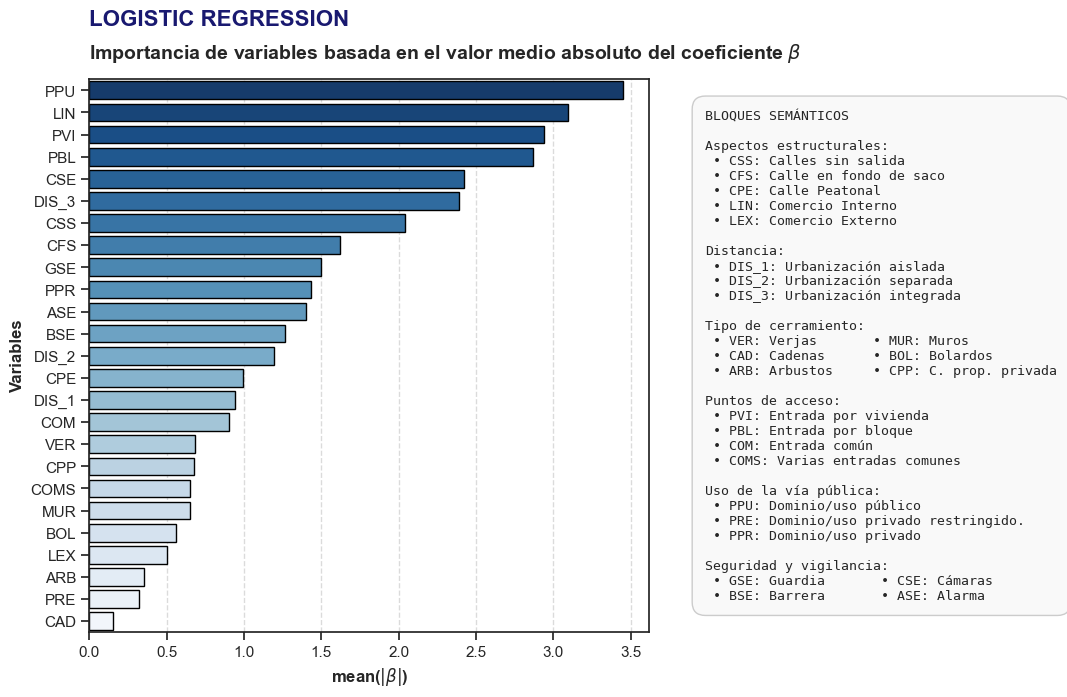

In [18]:
plot_lr_feature_importance(LR_coef_df, criterion="mean", figsize=[14, 7])

El gráfico de importancia global de variables muestra que el modelo de regresión logística multinomial basa sus predicciones en variables pertenecientes a distintos bloques semánticos, lo que indica que la clasificación no depende de un único bloque de variables, sino que integra información morfológica urbana diversa.

La variable con mayor relevancia para el modelo es el uso y dominio público de la vía (**PPU**). El dominio privado y de uso privado (**PPR**) alcanza aproximadamente la mitad de la importancia de **PPU**, mientras que el uso privado con acceso público restringido (**PRE**) apenas influye al presentar coeficientes medios próximos a cero. Esto muestra como el bloque de "Uso de la vía pública" es relevante cuando su significado semántico está claramente definido, mediante un uso completamente público (**PPU**) o completamente privado (**PPR**).

La segunda variable más importante son los comercios internos (**LIN**), que pertenece al bloque de "Aspectos Estructurales". Otras variables de este bloque como las calles sin salida (**CSS**) y las calles en fondo de saco (**CFS**) presentan coeficientes medios elevados, mientras que los comercios externos (**LEX**) y las calles peatonales (**CPE**) se situan en la zona inferior del ranking.

En el bloque de "tipo de acceso" se destaca el acceso por vivienda (**PVI**) y por bloque (**PBL**) que ocupan la tercera y cuarta posición. Es destacable que para el modelo los tipos de acceso comunales (**COM** y **COMS**) tienen poca influencia, lo cual puede indicar que para clasificar el grado de cerramiento los accesos que implican mayor individualización son más discriminativos. 

El bloque de "Seguridad y vigilancia" concentra el mayor número de variables con coeficientes medios superiores a $1$. Dentro de este grupo destacan especialmente las cámaras de seguridad (**CSE**), aunque el resto de elementos de seguridad también presentan magnitudes relevantes. Esto sugiere que el modelo considera conjuntamente estas variables para discriminar entre los distintos grados de cerramiento.

Al mismo nivel de importancia que **CSE** se encuentra la variable **DIS_3** que codifica que el complejo residencial se encuentra integrado en el núcleo urbano. Sin embargo, las variables **DIS_2** y **DIS_1** que codifican el resto de tipos de distancia tienen una importancia muy reducida.

Uno de los resultados más llamativos del análisis es la escasa relevancia de las variables pertenecientes al bloque "Tipo de cerramiento", cuyos coeficientes medios permanecen por debajo de $0.5$. Desde una perspectiva urbanística, cabría esperar que estas características tuvieran una influencia más directa sobre la clasificación del grado de cerramiento. Sin embargo, el modelo parece apoyarse preferentemente en variables asociadas al tipo de acceso, seguridad, elementos viarios y tipo de uso de los mismos.

<a id="reg_cerramiento"></a>
## 1.2 Caracterización de los grados de cerramiento según la intensidad y dirección del efecto

En la sección anterior se ha utilizado el valor medio de la magnitud absoluta de los coeficientes para identificar las variables más influyentes desde una perspectiva global. En esta sección se profundiza en el análisis mediante el estudio del signo y la magnitud de los coeficientes asociados a cada grado de cerramiento.

Este enfoque permite caracterizar cada categoría a partir de las variables que el modelo considera más relevantes para su clasificación. El conjunto de estas variables define el “perfil” aprendido por el modelo para cada grado de cerramiento, identificando aquellas que contribuyen con mayor intensidad a aumentar o disminuir la probabilidad de pertenencia a una categoría concreta frente al resto.

Para llevar a cabo este análisis se ha desarrollado la función *plot_lr_class_coefs()*, encargada de generar un diagrama de barras horizontal con los coeficientes asociados a todas las variables para una clase específica. Con el objetivo de facilitar la comparación entre clases, la escala de representación se mantiene constante y se define a partir de los valores mínimo y máximo globales de los coeficientes del modelo.

Dado que las variables predictoras se encuentran organizadas en bloques semánticos, el gráfico agrupa las variables según dicha estructura y las ordena internamente en función de la magnitud de sus coeficientes. Esta representación permite interpretar tanto la relevancia individual de cada variable como la contribución conjunta de cada bloque semántico.

A continuación, se analiza esta representación para cada uno de los cinco grados de cerramiento.

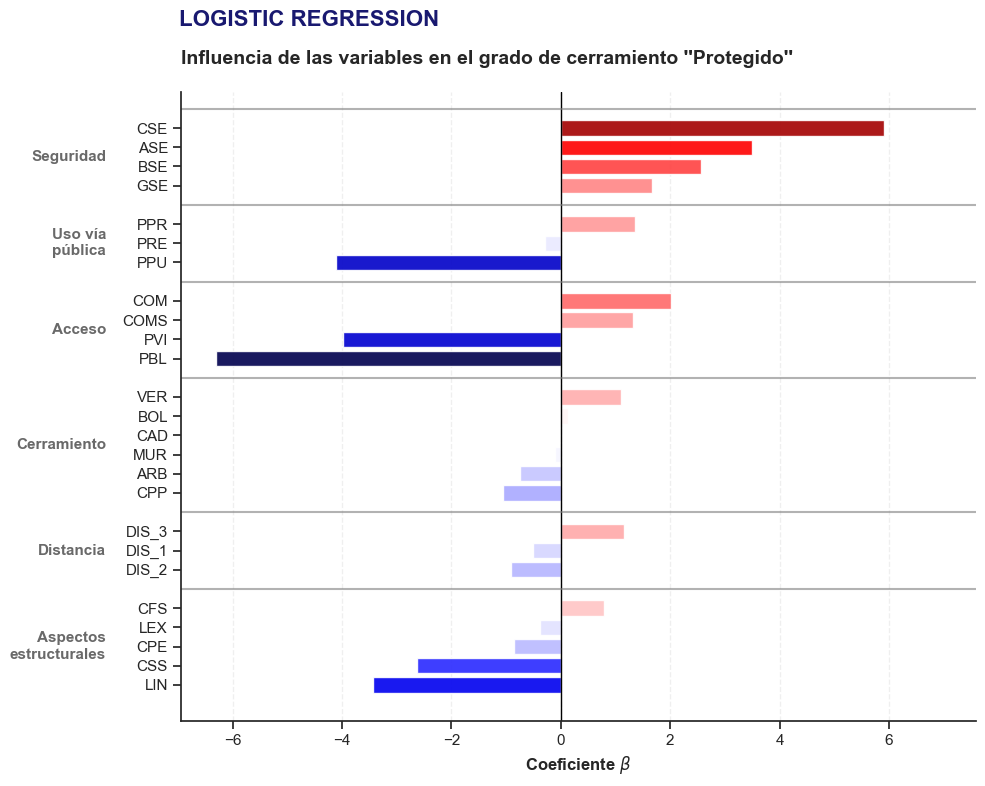

In [19]:
plot_lr_class_coefs(LR_coef_df, "Protegido")

El perfil aprendido por el modelo para identificar a la clase "Protegido" está claramente dominado por las variables del bloque semántico de seguridad, donde la presencia de cámaras de seguridad (**CSE**) destaca como el factor más influyente. En conjunto, estas variables actúan como catalizadores, cuya presencia contribuye a que un complejo residencial sea clasificado como "Protegido".

Los factores inhibidores del grado de cerramiento "Protegido" se distribuyen en varios bloques semánticos. Destacan principalmente los acceso por bloque (**PBL**) o por vivienda (**PVI**) junto al uso público de la vía (**PPU**). En menor medida, la presencia de elementos estrucurales internos como calles sin salida (**CSS**) o comercios internos (**LIN**) contribuyen a reducir la probabilidad de que el complejo residencial sea clasificado como "Protegido".

Puede interpretarse que el modelo caracteriza la clase “Protegido” como un tipo de complejo residencial fuertemente asociado a la presencia de servicios de seguridad y a la limitada existencia de espacios compartidos por no residentes. Esta configuración se refleja en la ausencia de comercios internos, la preferencia por el uso privado de la vía pública y el predominio de accesos comunales frente a accesos por vivienda o por bloque, lo que en conjunto reduce la permeabilidad y dificulta el tránsito de personas externas al complejo residencial.

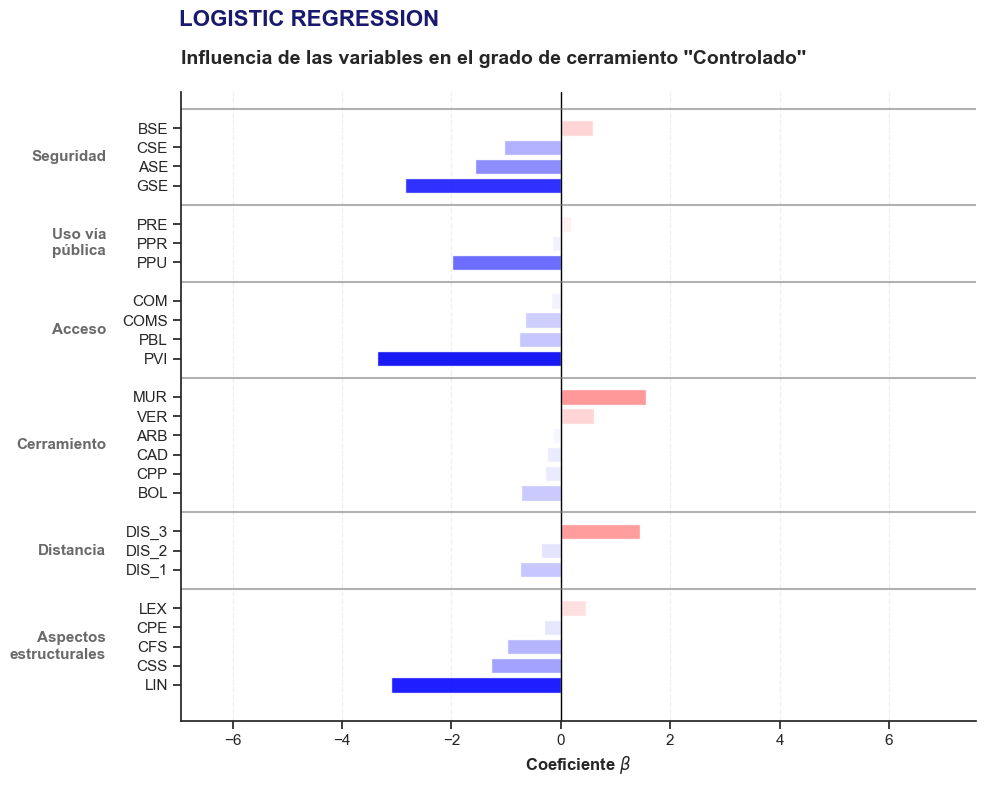

In [20]:
plot_lr_class_coefs(LR_coef_df, "Controlado")

Los coeficientes aprendidos por el modelo para la clase “Controlado” indican que esta categoría se caracteriza principalmente por la ausencia de variables, dado que los coeficientes de mayor magnitud en valor absoluto son negativos.

En este sentido, la presencia de comercios internos (**LIN**), acceso por vivienda (**PVI**) y uso público de la vía (**PPU**) actúan como factores inhibidores de la pertenencia a esta categoría. Este patrón es análogo a lo que ocurre en la categoría "Protegido". Sin embargo, en este caso la presencia de servicios de seguridad también contribuye a reducir la probabilidad de pertenecer a este grado de cerramiento.

Puede interpretarse que para el modelo, los complejos residenciales "Controlados" presentan un patrón de ausencia de características muy similar al de los complejos "Protegidos" pero diferencia ambas categorías a través de los servicios de seguridad, que actuan como catalizadores del grado de cerramiento "Protegido" y como inhbidores del grado de cerramiento "Controlado".

Este análisis permite caracterizar el grado de cerramiento "Controlado" como complejos residenciales que no presentan espacios de tránsito para no residentes pero que no cuentan con servicios de seguridad, por lo que la intensidad de cerramiento percibida queda matizada.

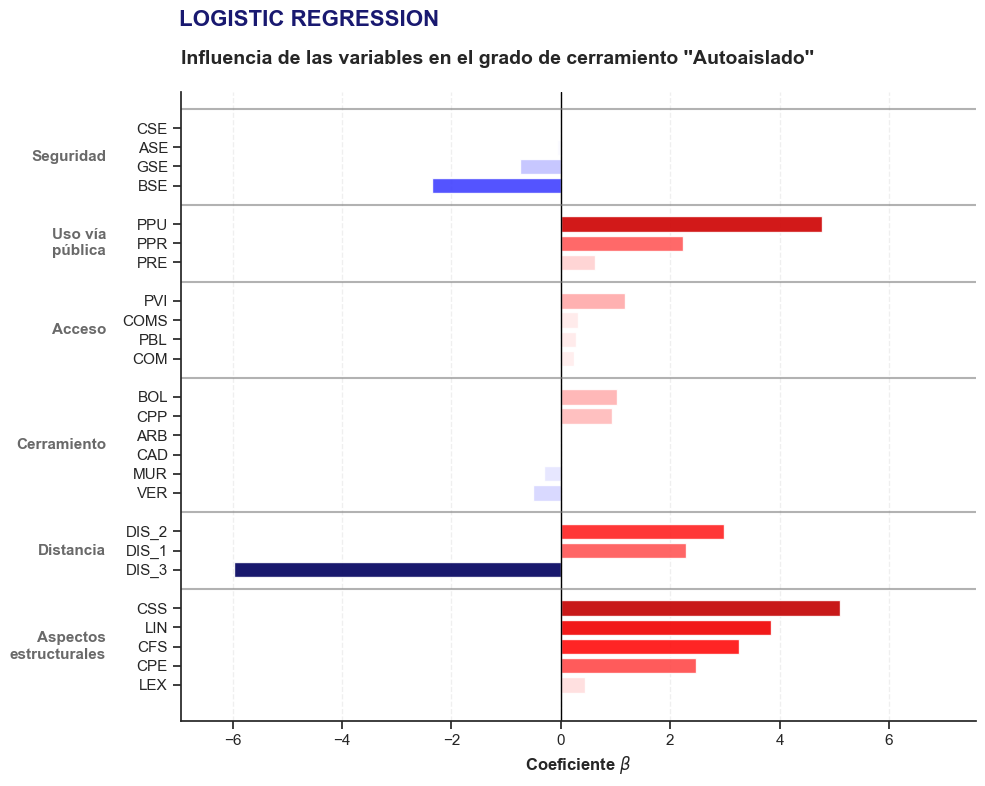

In [24]:
plot_lr_class_coefs(LR_coef_df, "Autoaislado")

En el grado de cerramiento “Autoaislado” se observa un patrón conformado por múltiples variables catalizadoras y una clara variable inhibidora que actúa como principal elemento discriminante de esta categoría.

El bloque semántico de aspectos estructurales se destaca como el principal catalizador de este grado de cerramiento. La presencia de vias internas como calles sin salida (**CSS**), calles en fondo de saco (**CFS**) y calles peatonales (**CPE**) junto a la presencia de comercios internos contribuyen a que un complejo residencial sea clasificado como "Autoaislado".

El principal factor inhibidor pertenece al bloque semántico de la distancia. La variable **DIS_3**, que codifica que el complejo residencial se encuentra integrado en el núcleo urbano, reduce notablemente las probabilidades del grado de cerramiento "Autoaislado". Este valor tan negativo del coeficiente de **DIS_3**, es coherente con lo observado en el análisis exploratorio, donde ningún complejo residencial "Autoaislado" del conjunto de datos tiene esta variable activa. Como consecuencia, el modelo de regresión logística obtiene un coeficiente negativo con un valor de magnitud absoluta muy alto.

Por lo tanto, las otras variables de distancia (**DIS_1** y **DIS_2**) se comportan como catalizadores. Estas variables indican que el complejo residencial está aislado o separado, respectivamente, del núcleo úrbano.

En relación con el uso de la vía pública, se observa que tanto el uso público (**PPU**) como el uso privado (**PPR**) contribuyen positivamente a la clasificación, aunque con distinta intensidad. Esto sugiere que, en este caso, la distinción entre ambos tipos de uso no resulta altamente discriminativa para este grado de cerramiento.

Puede concluirse que el modelo caracteriza el grado de cerramiento "Autoaislado" como un tipo de complejo residencial no integrado en el núcleo urbano, con presencia significativa de estructura viaria interna cuyo uso puede ser tanto público como privado.

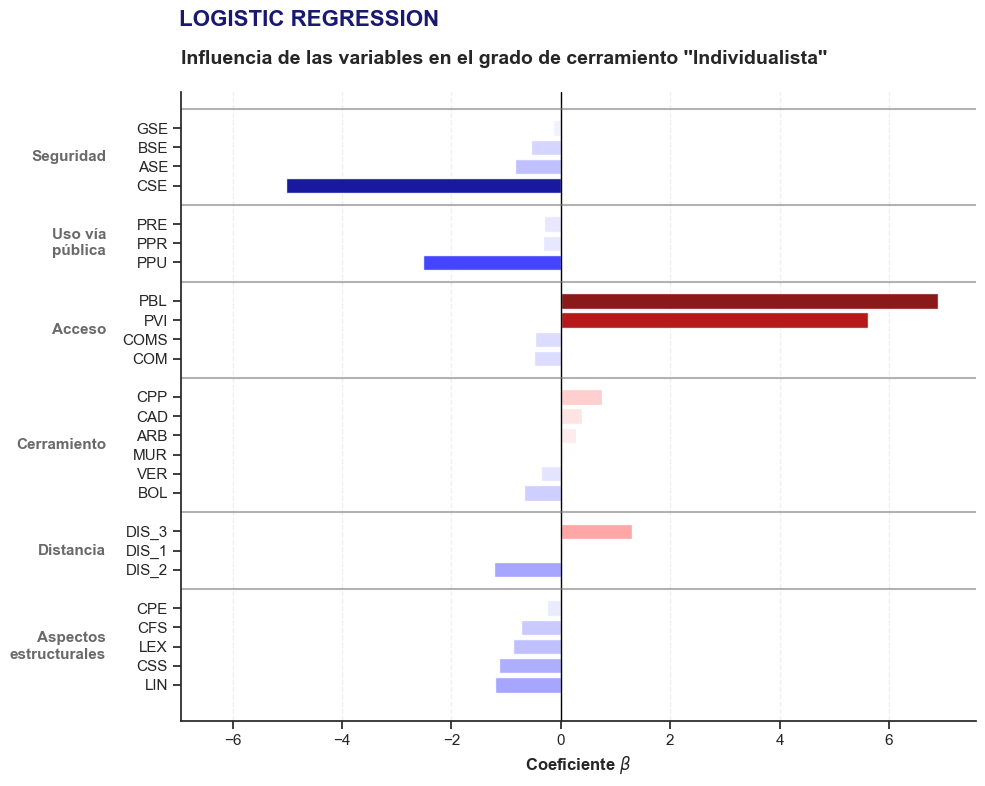

In [22]:
plot_lr_class_coefs(LR_coef_df, "Individualista")

La clase “Individualista” se caracteriza por un número reducido de variables que presentan una influencia claramente dominante frente al resto.

El modelo identifica como principales factores catalizadores los accesos por bloque (**PBL**) y por vivienda (**PVI**), que incrementan de forma significativa la probabilidad de pertenencia a esta categoría. En contraste, la ausencia de cámaras de seguridad (**CSE**) y el uso público de la vía (**PPU**) actúan como principales factores inhibidores. 

Ninguna de las variables asociadas al uso de la vía (**PPU**, **PPR** y **PRE**) presenta coeficientes positivos. Este resultado, junto con el hecho de que las variables del bloque de aspectos estructurales actúan como inhibidores con coeficientes de magnitud relativamente baja, sugiere que los complejos residenciales “Individualistas” tienden a presentar una escasa o nula estructuración viaria interna, lo que se traduce, de forma coherente, en una ausencia de usos asociados a dicha red viaria.

El resto de variables presentan coeficientes de magnitud reducida, lo que indica una capacidad explicativa limitada dentro de este grado de cerramiento. 

Este grado de cerramiento puede interpretarse como un tipo de complejo residencial caracterizado por un acceso individual o a través de bloque sin estructura viaria interna ni mecanismos de seguridad.

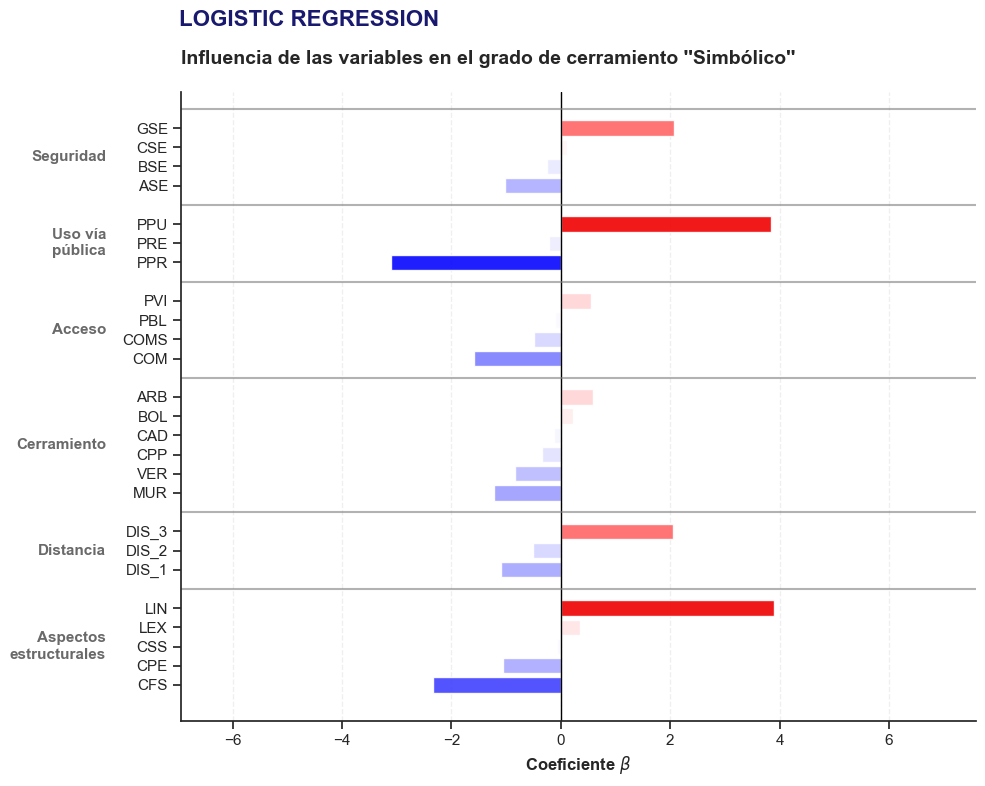

In [23]:
plot_lr_class_coefs(LR_coef_df, "Simbólico")

El perfil de los complejos residenciales "Simbólicos" aprendido por el modelo está fuertemente determinado por las variables asociadas al uso de la vía pública. En este sentido, el dominio y uso público (**PPU**) actúa como principal factor catalizador, mientras que el uso privado (**PPR**) presenta un efecto inhibidor de magnitud similar. Esto sugiere que la distinción entre ambos extremos del uso del espacio viario contribuye fuertemente a clasificar este grado de cerramiento.

Los comercios internos (**LIN**) se comportan como el otro gran factor catalizador. Sin embargo, las variables de calles internas presentan coeficientes negativos en este grado de cerramiento.

Por último, destaca que la presencia de guardias de seguridad (**GSE**) contribuya de forma positiva a la probabilidad de pertenencia al grado de cerramiento “Simbólico”, lo cual no se alinea con el conocimiento urbanístico asociado a esta categoría, entendida como el nivel más sutil de cerramiento.

No obstante, debe tenerse en cuenta que esta clase presenta el rendimiento más bajo entre los modelos evaluados. En el caso de la regresión logística, su precisión es notablemente reducida, por lo que la interpretabilidad de los coeficientes que podría estar reflejando patrones menos estables o menos representativos.

Bajo esta premisa, puede concluirse que el modelo caracteriza el grado de cerramiento “Simbólico” como complejos residenciales que cuentan con elementos que favorecen el tránsito de no residentes y que por tanto diluyen la intensidad de cerramiento percibida, como la presencia de comercios internos y un uso público de la vía.

<a id="arbol"></a>
# 2. Interpretabilidad del árbol de decisión

La interpretabilidad global del árbol de decisión se aborda de forma análoga a la presentada en la sección anterior, mediante el análisis de la importancia global de las variables y la caracterización de cada grado de cerramiento. Para ello, se emplean dos mecanismos intrínsecos al propio modelo: la reducción de impureza y las reglas de decisión generadas por el árbol.

Se utiliza el modelo entrenado con el estimador *DecisionTreeClassifier* sobre todos los datos disponibles, que ha sido almacenado en *output/models/Decision_Tree_model.pkl*.

In [6]:
# Set pkl file path
DT_artifact_path =  os.path.join(models_folder,"Decision_Tree_model.pkl")

<a id="arbol_glob"></a>
## 2.1 Importancia global de las variables mediante reducción de impureza

A continuación se muestra un gráfico de barras que representa la importancia de las variables de acuerdo a la reducción acumulada de impureza que dicha variable produce a lo largo de todos los nodos en los que es utilizada para realizar una partición.

Decision_Tree model successfully loaded from pkl file.


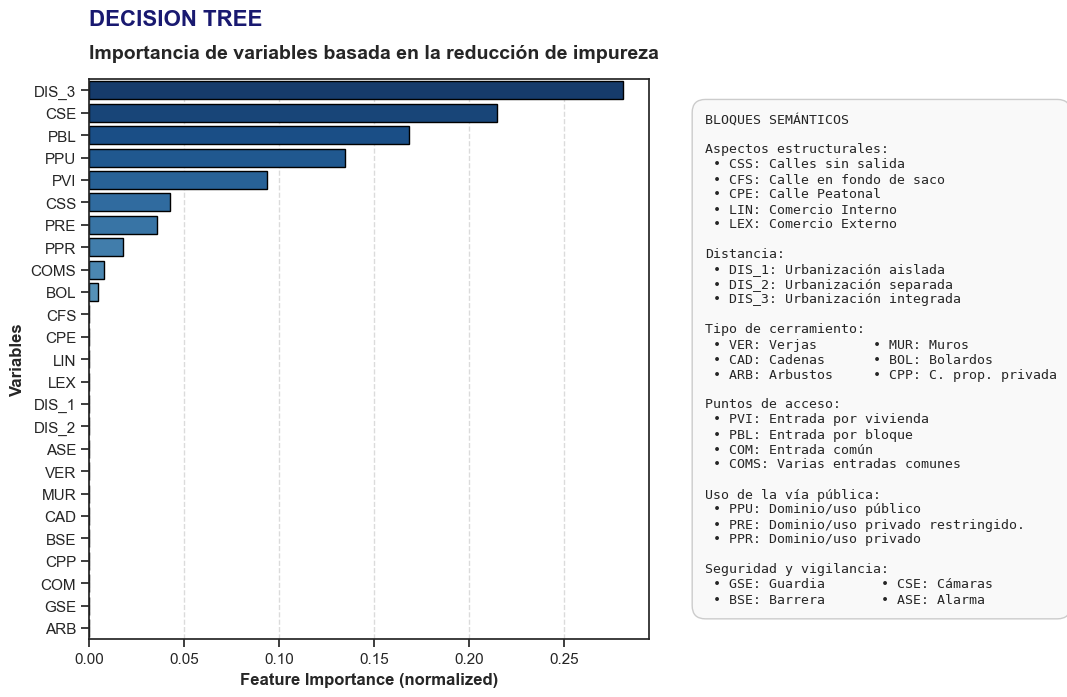

In [8]:
plot_tree_feature_importance(cfg, DT_artifact_path)

El gráfico de importancia de variables muestra que el árbol de decisión utiliza únicamente $10$ de las $25$ variables predictoras disponibles para realizar la clasificación. Esto indica que el modelo lleva a cabo una selección implícita de características, empleando únicamente aquellas variables con mayor capacidad discriminativa en las particiones del espacio de características, lo que favorece una mayor interpretabilidad. Esta selección no solo es consecuencia del funcionamiento inherente del algoritmo, sino también de la configuración de hiperparámetros realizada, que ha limitado el crecimiento del árbol con el objetivo de preservar su carácter interpretable.

La variable con mayor importancia en la partición del espacio de características es **DIS_3**, que representa la integración del complejo residencial dentro del núcleo urbano. A continuación, le siguen las cámaras de seguridad (**CSE**), al acceso por bloque (**PBL**) y al uso público de la vía (**PPU**).

De forma conjunta, los bloques de variables más relevantes para el árbol de decisión corresponden al tipo de acceso y al uso de la vía pública. En el bloque de tipo de acceso, el modelo utiliza $3$ de las $4$ variables disponibles, destacando principalmente el acceso por bloque (**PBL**) y el acceso por vivienda (**PVI**). En el bloque de uso de la vía pública, las tres variables disponibles (**PPU**, **PPR** y **PRE**) participan en las particiones del árbol, destacando con mayor importancia el uso público de la vía (**PPU**).

En conjunto, estos resultados indican que el árbol de decisión basa principalmente su capacidad de clasificación en cuatro dimensiones: la integración en el núcleo urbano, la presencia de cámaras de seguridad, el tipo de acceso y el uso de la vía.

Comparándo este analisis de importancia de variables, con el realizado en la sección anterior para el modelo de regresión logística, se observa que ambos modelos identifican como relevantes variables comunes como **PVI**, **PBL**, **PPU** y **DIS_3**. No obstante, existen algunas discrepancias. La variable **DIS_3** es claramente dominante en el árbol de decisión, mientras que en la regresión logística ocupa una posición intermedia dentro del ranking de importancia. Otro caso destacada es la variable de comercios internos (**LIN**), que se sitúa como la segunda variable más importante para el modelo de regresión logística pero el árbol de decisión no la utiliza en ninguna de sus particiones.

Estas diferencias se explican por la naturaleza del criterio de importancia en cada modelo. Mientras que el árbol prioriza variables con poder discriminativo localizado, la regresión logística valora contribuciones globales dentro de un modelo lineal. El criterio de reducción de impureza del árbol le lleva a una selección ímplicita de características. Una variable solo se incorpora si produce mejoras significativas en alguna partición concreta, y puede ser descartada si su información resulta redundante respecto a otras variables ya seleccionadas. Esto otorga al árbol de decisión una interpretabilidad más directa al utilizar un subcojunto reducido de variables.

Un ejemplo representativo de este comportamiento se observa en el bloque semántico de servicios de seguridad. Ambos modelos identifican este bloque relevante para la clasificación. Sin embargo, el árbol de decisión selecciona únicamente la variable de cámaras de seguridad (**CSE**), mientras que en la regresión logístca el resto de servicios de seguridad (**ASE**, **GSE** y **BSE**) presentan coeficientes con una magnitud elevada y que actuan en conjunto como catalizadores o inhibidores de determinados grados de cerramiento.

El árbol de decisión simplifica la representación del problema al centrarse únicamente en la variable de seguridad con mayor capacidad discriminativa, lo que facilita la interpretación de las reglas generadas. Sin embargo, esta simplificación puede reducir la capacidad de generalización del modelo. Por ejemplo, un complejo residencial que no disponga de cámaras de seguridad, pero sí de otros elementos de seguridad, podría no ser clasificado correctamente por el árbol.

En cambio, la regresión logística proporciona una representación más densa del problema, ya que incorpora simultáneamente todas las variables en el proceso de decisión. Aunque esto incrementa la complejidad interpretativa del modelo, le permite conseguir un mejor rendimiento en los casos que no se adecuan a los patrones más generales.

Esto pone de manifiesto el compromiso existente entre rendimiento  e interpretabilidad, incluso entre modelos inherentemente transparentes. En la evaluación de rendimiento se ha observado que el modelo de regresión logística presenta un desempeño superior al árbol de decisión. Este análisis de interpretabilidad permite comprender en mayor profundidad el posible origen de estas diferencias, mostrando el equilibrio entre diferentes mecanismos de interpretabilidad y la capacidad predictiva de los modelos.

<a id="arbol_cerramiento"></a>
## 2.2 Caracterización de los grados de cerramiento mediante reglas de decisión

Para caracterizar cada grado de cerramiento según el comportamiento aprendido por el árbol de decisión, se analizan las reglas de decisión que determinan la clasificación de las distintas categorías.

La visualización de la estructura del árbol se ha realizado mediante la función *get_visual_decision_tree()*, desarrollada en el módulo *src/XAI_utils.py*, la cual utiliza la librería *dtreeviz* (requiere la instalación del software *Graphviz* y su inclusión en el PATH del sistema).

Esta representación gráfica muestra la distribución de las clases en cada partición mediante diagramas de barras, mientras que en los nodos hoja se emplean diagramas de sectores para representar dicha distribución y el número de muestras totales mediante el tamaño. Se ha asignado un identificador numérico a cada hoja con el objetivo de facilitar la referencia durante el análisis de las reglas.

La estructura completa del árbol se ha exportado y almacenado como imagen en el directorio images/.

In [15]:
# Uncomment to update SVG file (images/viz_tree.svg)
# Graphviz software is required
#viz_tree = get_visual_decision_tree(cfg, DT_artifact_path)

<img src="../images/ARBOL_DE_DECISION_DTREEVIZ.jpg" alt="Estructura del árbol de decisión" width="90%">

Tal y como puede observarse en la estructura del árbol, el modelo genera un total de $15$ nodos hoja, lo que implica la existencia de $15$ reglas de decisión para la clasificación. La longitud máxima de estas reglas es de $6$ variables, correspondiente a la profundidad máxima establecida para el árbol durante el experimento. Esta restricción permite controlar la complejidad del modelo y preservar su interpretabilidad.

Con el objetivo de complementar el análisis de las reglas, en la siguiente tabla se presenta la distribución de clases en cada una de las hojas terminales. Esto permite cuantificar el grado de fiabilidad de las reglas de decisión  a través de su soporte (número total de muestras en la hoja) y la confianza (porcentaje de muestras de la clase dominante en la hoja).

In [16]:
leaf_df = get_leaf_classes_distribution(cfg, DT_artifact_path)

Decision_Tree model successfully loaded from pkl file.


Leaf_ID,Total_Muestras,Protegido (%),Controlado (%),Autoaislado (%),Individualista (%),Simbólico (%),Clase dominante
1,17,18.26,65.08,0.00,0.00,16.65,Controlado
2,7,0.00,24.61,0.00,75.39,0.00,Individualista
3,7,53.33,3.17,43.50,0.00,0.00,Protegido
4,33,0.00,0.00,0.00,91.08,8.92,Individualista
5,6,0.00,0.00,52.85,47.15,0.00,Autoaislado
6,14,0.00,0.00,95.88,0.00,4.12,Autoaislado
7,22,0.00,0.00,100.00,0.00,0.00,Autoaislado
8,239,4.56,81.59,0.00,0.00,13.86,Controlado
9,9,0.00,0.00,0.00,0.00,100.00,Simbólico
10,72,0.00,0.00,0.00,91.79,8.21,Individualista


A continuación, se analiza el conjunto de reglas asociado a cada grado de cerramiento. Para facilitar su identificación, cada regla se referencia mediante el identificador de la hoja correspondiente, lo que permite reconstruir el recorrido desde la raíz hasta el nodo terminal en la estructura del árbol, así como relacionarlo con la distribución de clases mostrada en la tabla.

El grado de cerramiento "Protegido" queda definido a través de dos reglas de decisión:
* **Regla ID=14:** $(DIS\_3 = 1 \land CSE = 1 \land PBL = 0) \implies \text{Protegido}$

    (Soporte: $n=67$, Confianza=$83.72\%$)
* **Regla ID=3.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land PPR=1) \implies \text{Protegido}$

    (Soporte: $n=7$, Confianza=$53.33\%$)

La regla $14$ presenta la mayor fiabilidad, ya que el $83.72\%$ de las muestras clasificadas en esta hoja pertenecen a la clase "Protegido". Además, se trata de una regla relativamente simple, compuesta únicamente por tres variables. Su interpretación semántica sugiere que los complejos residenciales protegidos suelen estar integrados en el núcleo urbano, disponer de cámaras de seguridad y no presentar acceso por bloque.

En cambio, la regla $3$ muestra una menor capacidad discriminativa, al tener un bajo soporte y confianza. Esta regla describe complejos no integrados en el núcleo urbano, sin calles sin salida, sin acceso por vivienda y con uso viario privado. 

En conjunto, ambas reglas reflejan patrones asociados a un grado de cerramiento elevado, especialmente a través del uso de cámaras de seguridad (**CSE**) y mediante la privatización del espacio vario (**PPR**).

El grado de cerramiento "Controlado" se define mediante de tres reglas de decisión:
* **Regla ID=15.** $(DIS\_3 = 1 \land CSE = 1 \land PBL = 1) \implies \text{Controlado}$

    (Soporte: $n=17$, Confianza=$66.5\%$)
* **Regla ID=8.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=0 \land PRE=0) \implies \text{Controlado}$

    (Soporte: $n=239$, Confianza=$81.59\%$)
* **Regla ID=1.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land PBL=0 \land PPR=0 \land PBL=0) \implies \text{Controlado}$

    (Soporte: $n=17$, Confianza=$65.08\%$)

En las tres hojas terminales, la clase “Controlado” es claramente dominante, destacando especialmente la regla 8, que presenta el mayor soporte. Este resultado indica que este grado de cerramiento está representado de forma consistente por el árbol de decisión.

La regla $15$ describe complejos residenciales integrados en el núcleo urbano, con cámaras de seguridad y acceso por bloque. La variable **PBL** constituye el principal elemento diferenciador respecto a la regla $14$ asociada al grado "Protegido".  El árbol distingue ambas categorías a partir del tipo de acceso: mientras que en el grado "Protegido" no existe acceso por bloque, en el grado "Controlado" este elemento reduce parcialmente la intensidad del cerramiento pese a mantener mecanismos de vigilancia como las cámaras de seguridad.

La regla $8$ representa el patrón más general dentro de esta categoría al concentrar el mayor número de muestras clasificadas como "Controlado". Esta regla agrupa complejos integrados en el núcleo urbano que no disponen de cámaras de seguridad (**CSE**) ni presentan acceso por vivienda (**PVI**) o por bloque (**PBL**), además de carecer de uso público (**PPU**) o público restringido (**PRE**) de la vía.

Por su parte, la regla $1$ describe complejos no integrados en el núcleo urbano, sin calles sin salida (**CSS**) y sin accesos por vivienda (**PVI**) o bloque (**PBL**). Además, no presentan uso público de la vía ni uso privado lo que sugiere que puedan carecer de estructura viaria interna. 

En conjunto el grado de cerramiento "Controlado" puede interpretarse como un nivel de cerramiento elevado pero que presenta al menos un elemento que suaviza dicha intensidad como la ausencia de cámaras de seguridad o el tipo de acceso por bloque.

El grado de cerramiento "Autoaislado" se define a través de tres reglas de decisión:
* **Regla ID=7.** $(DIS\_3 = 0 \land CSS = 1) \implies \text{Autoaislado}$

    (Soporte: $n=22$, Confianza=$100\%$)
* **Regla ID=6.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 1) \implies \text{Autoaislado}$

    (Soporte: $n=14$, Confianza=$95.88\%$)
* **Regla ID=5.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land COMS=1) \implies \text{Autoaislado}$

    (Soporte: $n=6$, Confianza=$52.85\%$)

Las reglas 7 y 6 presentan una clara dominancia de la clase “Autoaislado”, siendo la hoja 7 un nodo puro. En cambio, en la regla 5 coexisten muestras de las categorías “Autoaislado” e “Individualista” en proporciones similares, lo que indica una menor fiabilidad de esta regla.

La variable **DIS_3**, utilizada en la primera partición del árbol, resulta especialmente relevante para esta categoría, ya que agrupa completamente a los complejos residenciales "Autoaislados". Este comportamiento es coherente con el análisis exploratorio previo, donde se observó que no existen complejos de este tipo integrados en el núcleo urbano $(DIS_3 = 1)$.

Las reglas $7$ y $6$ describen configuraciones relativamente simples: complejos residenciales situados fuera del núcleo urbano que presentan algún elemento asociado al uso compartido del espacio. En la regla $7$, dicho comportamiento se relaciona con la presencia elementos disuasorios como las calles sin salida (**CSS**), mientras que en la regla $6$ aparece asociado al uso público de la vía (**PPU**).

La regla $5$ recoge un subconjunto más reducido de complejos residenciales que, no tienen calles sin salida ni uso público de la vía, pero presentan un tipo de acceso basado en varias entradas comunes (**COMS**).

En conjunto, las reglas muestran que el grado de cerramiento "Autoaislado" se caracteriza principalmente por la ausencia de integración en el núcleo urbano y por la existencia de elementos asociados al uso compartido del espacio residencial. Este último aspecto resulta especialmente relevante para diferenciar esta categoría de otros grados de cerramiento cuyas reglas también incluyen complejos residenciales situados fuera del núcleo úrbano.

Las reglas $3$ y $1$ correspondientes a las categorías "Protegido" y "Controlado", respectivamente, describen complejos residenciales no integrados en el núcleo urbano, pero en esos casos el espacio residencial no cuenta con elementos compartidos o su uso es privado.

Este análisis revela que los complejos residenciales "Autoaislados" son accesibles para no residentes y su cerramiento queda definido a través de su situación geográfica y la presencia de elementos disuasorios para no residentes, como calles sin salida. 

El grado de cerramiento "Individualista" queda definido mediante cinco reglas de decisión. Las dos primeras pertenecen a la rama izquierda del árbol y, por tanto, describen complejos residenciales no integrados en el núcleo urbano $(DIS_3 = 0)$:

* **Regla ID=2.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=0 \land PPR=0 \land PBL=1) \implies \text{Individualista}$

    (Soporte: $n=7$, Confianza=$75.39\%$)
* **Regla ID=4.** $(DIS\_3 = 0 \land CSS = 0 \land PPU = 0 \land PVI=1 \land COMS=0) \implies \text{Individualista}$


    (Soporte: $n=33$, Confianza=$91.08\%$)

Ambas reglas pueden interpretarse de forma conjunta puesto que el factor diferencial reside en el tipo de acceso. Los complejos residenciales que no están integrados en el núcleo úrbano son clasificados como "Individualistas" si no tienen uso de la vía pública (**PPU**) ni calles sin salida (**CSS**) pero acceden a través de bloque (**PBL**) o a través de vivienda (**PVI**).

En la rama derecha del árbol, los complejos residenciales integrados en el núcleo urbano $(DIS_3 = 1)$ quedan definidos mediante tres reglas adicionales:
* **Regla ID=12.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=1) \implies \text{Individualista}$
    
    (Soporte: $n=91$, Confianza=$90.35\%$)
* **Regla ID=10.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=1 \land BOL=0) \implies \text{Individualista}$
    
    (Soporte: $n=72$, Confianza=$91.79\%$)
* **Regla ID=11.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=1 \land PBL=1) \implies \text{Individualista}$
    
    (Soporte: $n=16$, Confianza=$58.04\%$)

La interpretación de estas reglas es prácticamente equivalente a la observada en la rama izquierda, lo que indica que la variable **DIS_3** no resulta especialmente discriminativa para esta categoría. De nuevo, la clasificación depende del tipo de acceso y se añade la ausencia de cámaras de seguridad. De este modo, los complejos residenciales integrados en el núcleo urbano son clasificados como "Individualistas" cuando no disponen de cámaras de seguridad (**CSE**), no presentan uso público de la vía (**PPU**) y el acceso se realiza por vivienda (**PVI**) o por bloque (**PBL**).

Además, las reglas $10$ y $11$ evidencian una partición redundante del árbol, ya que la variable bolardos (**BOL**) no modifica la clase dominante en ninguna de las dos hojas terminales.

Aunque este grado de cerramiento se asocia a cinco reglas de decisión, su interpretación se reduce principalmente al tipo de acceso, por vivienda o por bloque. Además, las reglas muestran que en los complejos integrados en el núcleo úrbano no hay cámaras de seguridad, mientras que en los ubicados fuera del núcleo pueden existir o no, sin que ese factor resulte determinante para la clasificación como "Individualista".

Finalmente, el grado de cerramiento "Simbólico" queda definido mediante dos reglas de decisión:
* **Regla ID=13.** $(DIS\_3 = 1 \land CSE = 0 \land PPU = 1) \implies \text{Simbólico}$

    (Soporte: $n=25$, Confianza=$100\%$)
* **Regla ID=9.**  $(DIS\_3 = 1 \land CSE = 0 \land PPU = 0 \land PVI=0 \land PBL=0 \land PRE=1) \implies \text{Simbólico}$

    (Soporte: $n=22$, Confianza=$100\%$)

Las hojas terminales asociadas a ambas reglas son completamente puras, ya que únicamente contienen complejos residenciales clasificados como "Simbólico". Esto proporciona una elevada fiabilidad interpretativa a estas reglas.

Las dos reglas comparten una misma estructura basada en la integración en el núcleo urbano y la ausencia de cámaras de seguridad. La diferencia entre ambas reside en el tipo de uso del espacio viario. La regla $13$, que representa el caso más frecuente, describe complejos con uso público de la vía (**PPU**), mientras que la regla $9$ recoge complejos con uso público restringido (**PRE**) siempre y cuando el tipo de acceso no sea por vivienda (**PVI**) ni por bloque (**PBL**). 

Desde una perspectiva urbanística, estas reglas reflejan un grado de cerramiento débil lo cual resulta coherente con la propia naturaleza de la categoría "Simbólico", que constituye el grado de cerramiento más sútil y difuminado.

La clase “Simbólico” ha resultado la más difícil de clasificar para los modelos. En el árbol de decisión se observa un recall bajo, aunque con una precision elevada, lo que se refleja en la existencia de reglas de decisión con hojas puras y, por tanto, interpretaciones más fiables. En el caso de la regresión logística, la precision para esta categoría es más baja, lo que reduce la robustez interpretativa del modelo en esta clase. Sin embargo, el recall es notablemente más alto, lo que se traduce en un mejor rendimiento global para esta categoría. Este comportamiento pone de manifiesto el compromiso existente entre interpretabilidad y rendimiento en función del objetivo del análisis.

<a id="caja_negra"></a>
# 3. Interpretabilidad de modelos caja negra

Para realizar el análisis de interpretabilidad de los modelos caja negra (SVM, Random Forest y XGBoost) se aplica la técnica post-hoc SHAP (*SHapley Additive exPlanations*).

En primer lugar, se llevará a cabo un análisis global de importancia de variables sobre los tres modelos. El objetivo de esta primera fase es evaluar la consistencia del conocimiento extraído por diferentes arquitecturas de aprendizaje de mayor complejidad. Esto permite verificar si los patrones identificados son inherentes a los datos o si están influenciadas por la arquitectura de un algoritmo en concreto. Asimismo, se evaluará si las variables más influyentes identificadas con SHAP coinciden con las obtenidas mediante los mecanismos de explicabilidad intrínseca de los modelos transparantes.

Posteriormente, se realiza un análisis de interpretabilidad en mayor profundiad centrado exclusivamente en el modelo XGBoost. En esta fase se caracterizan los grados de cerramiento mediante las variables más relevantes en función de la magnitud y dirección del efecto sobre la salida del modelo. Este análisis desagregado por clase se centra en XGBoost puesto que es el modelo con mejor rendimiento predicitvo en el experimento. En este sentido, se convierte en el principal candidato para priorizar rendimiento frente a un modelo transparante, por lo que es especialmente relevante conocer en profundidad como el modelo utiliza las variables para realizar la clasificación.

<a id="caja_negra_glob"></a>
## 3.1 Importancia global de variables mediante SHAP

El estudio de la importancia global de variables mediante SHAP se apoya en dos visualizaciones complementarias:
* **Gráfico de barras de importancia global**. Este gráfico actúa como un indicador global de la contribución de cada variable al comportamiento del modelo. Se calcula promediando los valores absolutos SHAP de cada característica en todas las observaciones y clases. Al utilizar valores absolutos, se mide la capacidad de la variable para alterar la predicción, independientemente de si la "empuja" hacia arriba o hacia abajo.

* **Mapa de calor (Heatmap) de valores SHAP por clase**. Muestra la contribución media de cada variable predictora desagregada por clase. Esta representación permite analizar cómo varía la relevancia de las variables en función de cada categoría de la variable objetivo, proporcionando una visión más detallada del comportamiento del modelo.

A continuación, se calculan los valores SHAP de cada modelo mediante la librería *shap*, empleando el método Kernel SHAP para el modelo SVM y Tree SHAP para los modelos basados en árboles de decisión. 

El *array* resultante, que contiene los valores SHAP, tiene dimensiones $(642, 25, 5)$ correspondientes a:
* 642 observaciones utilizadas para el entrenamiento del modelo.
* 25 variables predictoras.
* 5 categorías asociadas a la variable objetivo.

In [6]:
# Set path to model PKL files
SVM_artifact_path =  os.path.join(models_folder, "SVM_model.pkl")
RF_artifact_path =  os.path.join(models_folder, "Random_Forest_model.pkl")
XG_artifact_path =  os.path.join(models_folder, "XGBoost_model.pkl")

In [7]:
#################
# SVM
#################

# Uncomment to recalculate shap values for SVM 

#shap_values_SVM = get_shap_svm(cfg, SVM_artifact_path)

# The values has been stored in output/SHAP_global/SVM_shap_global.npy to avoid SHAP calculation time (approx 20 minutes)
shap_values_SVM = np.load("../output/SHAP_global/SVM_shap_global.npy")

In [8]:
#################
# Random Forest
#################
shap_values_RF = get_shap_tree(cfg, RF_artifact_path)

Random_Forest model successfully loaded from pkl file.
Get shap values with KernelExplainer...
Shap values calculated succesfully.
Array size: (642, 25, 5)

Saving results...
Output directory: C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\TFM\PROJECT\output\SHAP_global


In [9]:
#################
# XGBoost
#################
shap_values_XG = get_shap_tree(cfg, XG_artifact_path)

XGBoost model successfully loaded from pkl file.
Get shap values with KernelExplainer...
Shap values calculated succesfully.
Array size: (642, 25, 5)

Saving results...
Output directory: C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\TFM\PROJECT\output\SHAP_global


A continuación se muestran el gráfico de barras de importancia global de variables para los tres modelos.

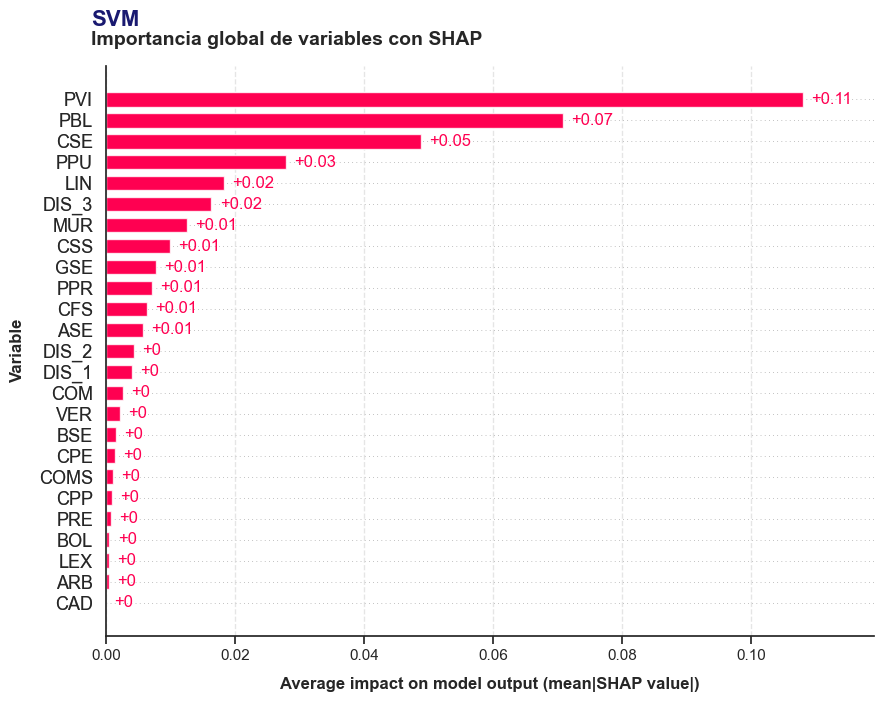

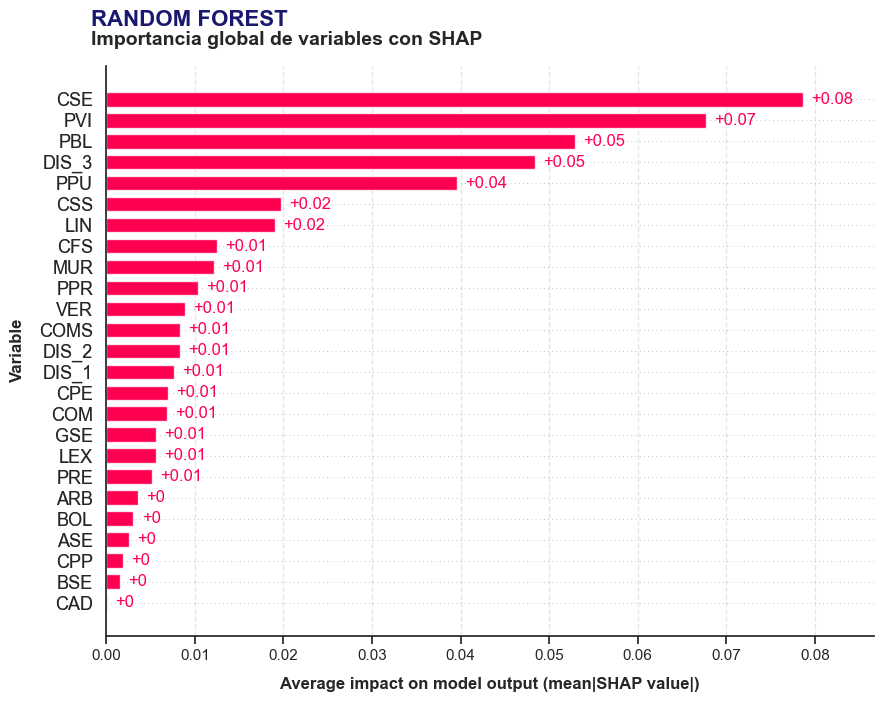

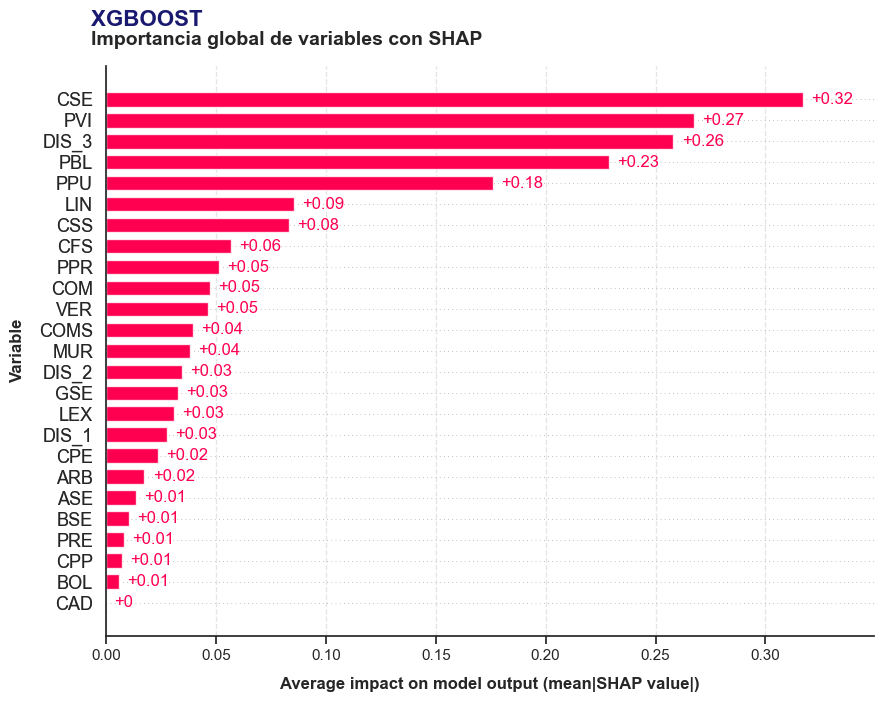

In [11]:
plot_shap_global_feature_importance(cfg, shap_values_SVM, model_name="SVM", num_features_display=25, figsize=[9,7])
plot_shap_global_feature_importance(cfg, shap_values_RF, model_name="Random Forest", num_features_display=25, figsize=[9,7])
plot_shap_global_feature_importance(cfg, shap_values_XG, model_name="XGBoost", num_features_display=25, figsize=[9,7])

Los gráficos SHAP muestran una alta consistencia entre los tres modelos "caja negra". Las variables **CSE**, **PVI**, **PBL** y **PPU** se destacan como las más relevantes en los tres modelos con ligeras variaciones en el orden. Este resultado indica que las variables morfológicas urbanas más críticas para determinar el grado de cerramiento se mantienen estables, independientemente de la arquitectura y el mecanismo de aprendizaje del algoritmo empleado. Puede concluirse que los patrones identificadas constituyen una señal real e inherente a los datos y no a un artefacto o sesgo inductivo de un modelo particular.

La principal diferencia entre los modelos reside en como se reducen los valores SHAP a partir de la quinta variable predictora más relevante. En SVM y Random Forest se observa una rápida convergencia de los valores SHAP hacia contribuciones próximas a cero. Por el contrario, en XGBoost se mantiene una distribución de importancia más gradual y escalonada.

Este comportamiento puede explicarse por la naturaleza secuencial del algoritmo Gradient Boosting, en el que cada árbol se entrena para corregir los errores residuales de las iteraciones anteriores. Los primeros árboles se enfocan en los casos fáciles, dominados por las variables más influyentes. Una vez que esas variables ya no pueden explicar más variabilidad, XGBoost se ve obligado a explotar la información de variables "secundarias" para corregir los errores más finos asociados a los casos dificiles. Este análisis refuerza el resultado obtenido en la evaluación de rendimiento, donde XGBoost es superior en capacidad predictiva a SVM y Random Forest.

Además de la consistencia observada entre los modelos "caja negra", también existe concordancia con las variables más influyentes de los modelos transparentes según su interpretabilidad intrínseca. En la siguiente tabla se muestra el top 5 de variables más importantes a nivel global para cada modelo:

**Tabla Comparativa de Importancia de Variables (Top 5)**

| Posición | Regresión Logística (Coeficientes) | Árbol de Decisión (Impureza) | SVM (SHAP Global) | Random Forest (SHAP Global) | XGBoost (SHAP Global) |
| :---: | :--- | :--- | :--- | :--- | :--- |
| **1º** | PPU | DIS_3 | PVI | CSE | CSE |
| **2º** | LIN | CSE | PBL | PVI | PVI |
| **3º** | PVI | PBL | CSE | PBL | DIS_3 |
| **4º** | PBL | PPU | PPU | DIS_3 | PBL |
| **5º** | CSE | PVI | LIN | PPU | PPU |

Como puede observarse, el conjunto de variables **PPU**, **PVI**, **PBL** y **CSE** se mantienen en el top-5 de los cinco modelos. Las variables **DIS_3** y **LIN** son las que varían entre modelos.

Esta consistencia entre la importancia de variables en modelos "caja negra" y modelos interpretables revela que los modelos de mayor complejidad se basan en los mismos pilares conceptuales que los modelos transparentes y mejoran su capacidad predictiva con una modelización más compleja de dichas variables.

Este resultado pone de manifiesto que el uso de SHAP aporta a los modelos "caja negra" un nivel de interpretabilidad conceptual equivalente al obtenido con los mecanismos intrínsecos en los modelos transparentes, aunque no se cuente con la inspección matemática directa de su estructura interna, como sí ocurre en estos últimos.

Tras analizar la importancia de las variables en los diferentes modelos puede concluirse que la clasificación del grado de cerramiento está principalmente determinada por cuatro dimensiones semánticas de la morfología úrbana: los servicios de seguridad, la integración en el núcleo úrbano, el tipo de acceso y el uso de la vía.

Las variables del bloque "Aspectos estructurales" presentan una importancia intermedia, destacando los comercios internos (**LIN**) y las calles sin salida (**CSS**). Por el contrario, el bloque de tipos de cerramiento es el que menor impacto tiene en todos los modelos. Únicamente en XGBoost se observa una contribución no despreciable de elementos como los muros (**MUR**) y las verjas (**VER**), aunque su relevancia sigue siendo reducida en comparación con el resto de variables. Este comportamiento muestra la capacidad de XGBoost para capturar patrones más complejos, incorporando información de variables que en otros modelos tienen un papel prácticamente residual.

A continuación se presenta la importancia global de las variables desagregada por cada grado de cerramiento para los tres modelos "caja negra". Este nivel de importancia se calcula como la media del valor absoluto de los valores SHAP para cada clase, considerando todas las observaciones del conjunto de datos.

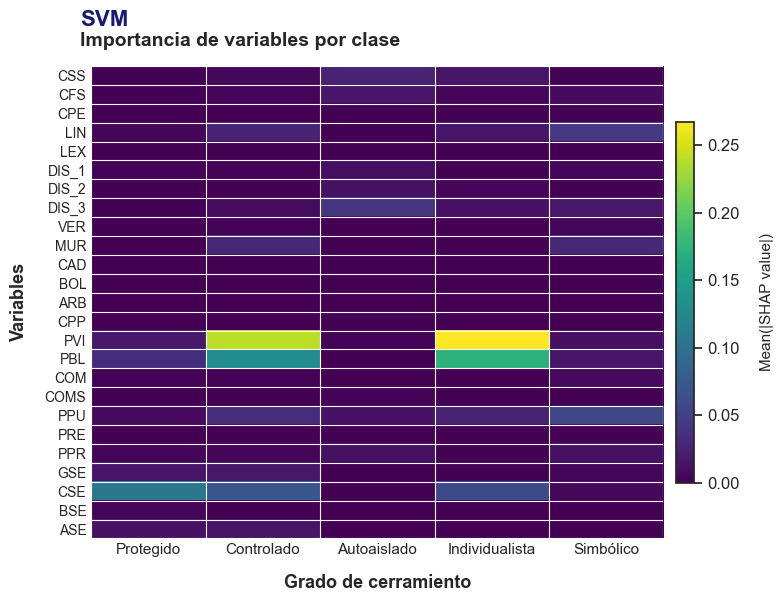

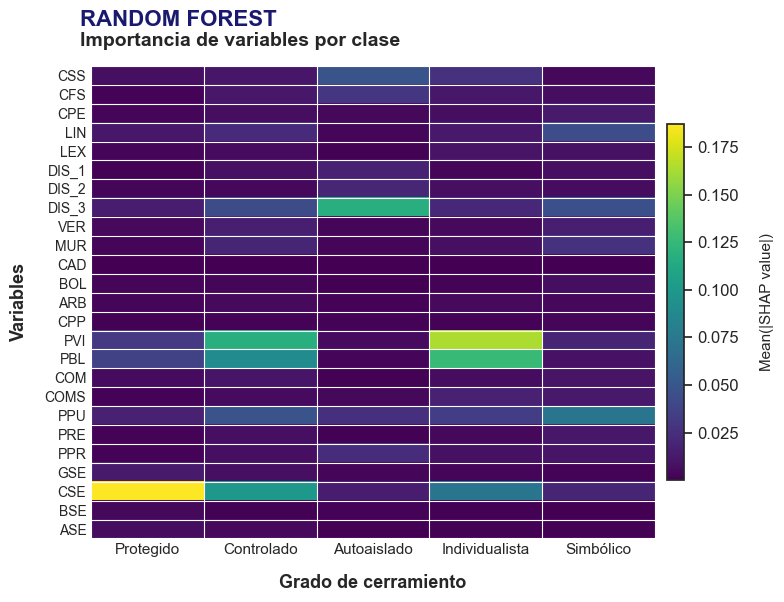

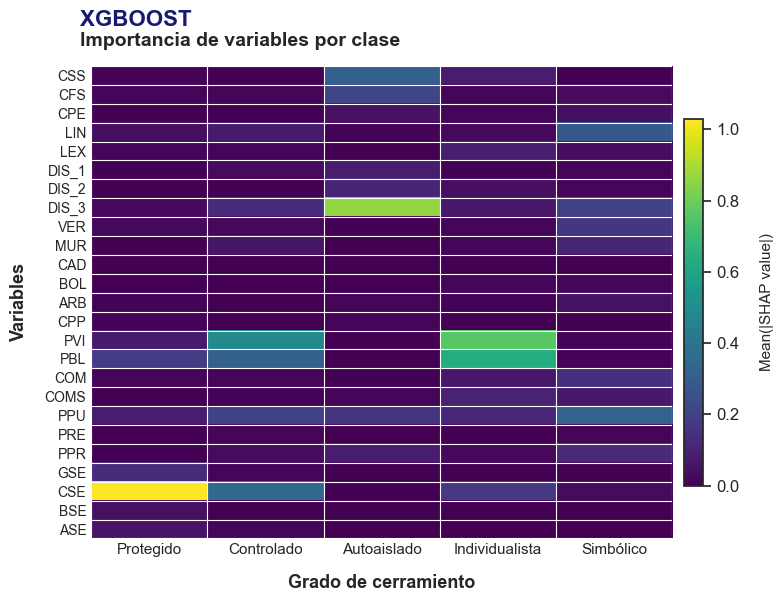

In [22]:
plot_shap_heatmap(cfg, shap_values_SVM, "SVM", figsize=[8, 6])
plot_shap_heatmap(cfg, shap_values_RF, "Random Forest", figsize=[8, 6])
plot_shap_heatmap(cfg, shap_values_XG, "XGBoost", figsize=[8, 6])

Tal y como se observa en los gráficos, los resultados muestran una alta consistencia entre modelos a nivel de clase, especialmente entre XGBoost y Random Forest.

En los tres modelos, los tipos de acceso destacan como variables relevantes en las clases “Controlado” e “Individualista”. En contraste, la integración en el núcleo urbano (**DIS_3**) y las cámaras de seguridad (**CSE**) presentan menor impacto en SVM, mientras que en Random Forest y XGBoost adquieren mayor relevancia, contribuyendo principalmente a las clases “Autoaislado” y “Protegido”, respectivamente. En el caso del grado de cerramiento “Simbólico”, no se identifica ninguna variable claramente dominante en ninguno de los modelos.

<a id="caja_negra_cerramiento"></a>
## 3.2 Caracterización de los grados de cerramiento mediante SHAP en el modelo óptimo (XGBoost)

Tras el análisis de importancia global de variables en los tres modelos "caja negra", se procede a realizar un análisis de interpretabilidad desagregado por clase enfocado en el modelo XGBoost.

Para llevar a cabo este estudio detallado se emplean dos visualizaciones complementarias:
* **Gráfico de barras de importancia por clase**. Representa la media del valor absoluto de los valores SHAP para cada variable predictora dentro una clase concreta. Esta métrica cuantifica el peso de cada característica en la discriminación de esa categoría específica.

* **Gráfico de densidad Beeswarm**. Esta visualización representa la distribución de los valores SHAP de todas las observaciones para una clase concreta. Cada punto corresponde a una observación individual, y su posición en el eje horizontal indica el valor SHAP, es decir, su contribución a la predicción. Esta representación permite analizar simultáneamente la magnitud, dirección y dispersión del impacto de cada variable. Los valores SHAP positivos indican que la variable empuja la predicción hacia la pertenencia a la clase analizada, mientras que los valores negativos indican el efecto opuesto. Asimismo, la dispersión de los puntos permite identificar si el impacto de una variable es homogéneo o varía entre observaciones.  El color de los puntos codifica el valor de la variable original, donde el azul representa la ausencia de la característica (valor 0) y el rojo la presencia de la característica (valor 1). De este modo, es posible identificar variables catalizadoras e inhibidoras de forma similar a lo realizado en el análisis de interpretabilidad de la regresión logística.

A continuación se analiza la interpretabilidad de cada grado de cerramiento.

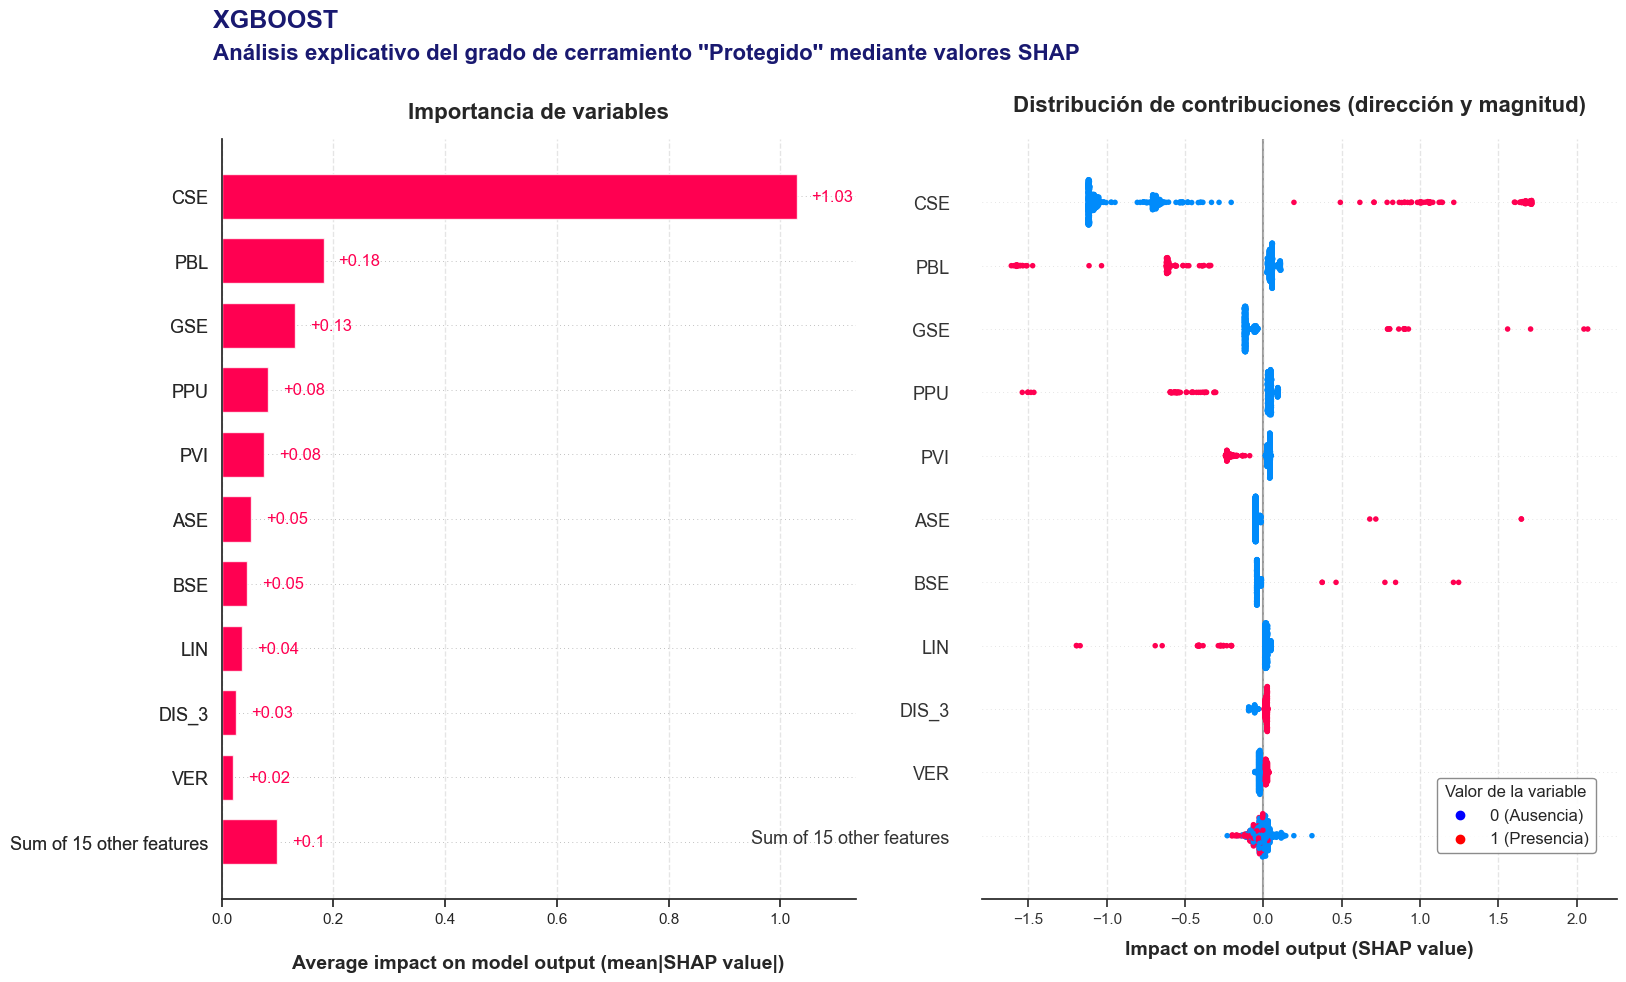

In [17]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Protegido", model_name="XGBoost", num_features_display=11)

En el grado de cerramiento "Protegido", la variable con mayor impacto promedio sobre las predicciones del modelo es las cámaras de seguridad (**CSE**). Al examinar el gráfico *beeswarm*, se identifica que la existencia de cámaras de seguridad actúa como un claro catalizador para la asignación de esta categoría, mientras que su ausencia reduce drásticamente la contribución de pertenecer a ella.

El resto de servicios de seguridad (**ASE**, **BSE** y **GSE**) exhiben un comportamiento asimétrico: presentan valores SHAP elevados y positivos cuando están presentes en el complejo residencial, pero su ausencia no penaliza ni reduce la contribución a este grado de cerramiento de forma tan marcada como **CSE**.

Este comportamiento del modelo es coherente con los hallazgos del análisis exploratorio de datos (EDA), donde se identificó que las cámaras de seguridad son un elemento mucho más frecuente en los complejos residenciales "Protegidos" que el resto de los servicios de seguridad. El modelo captura con éxito que, si bien la presencia de cualquier servicio de seguridad contribuye positivamente para la clase "Protegido", únicamente la ausencia de cámaras de seguridad funciona como un factor inhibidor crítico. 

Al margen de las variables de servicios de seguridad, la presencia de comercios internos (**LIN**), el uso público de la vía (**PPU**) y los accesos directos por vivienda (**PVI**) o bloque (**PBL**) se comportan como los principales factores inhibidores para este grado de cerramiento.

La interpretación urbanística de este grado de cerramiento queda definida por la presencia de servicios de seguridad que marcan un control del cerramiento intenso y por la ausencia de espacios comunes que posibiliten la presencia de no residentes.

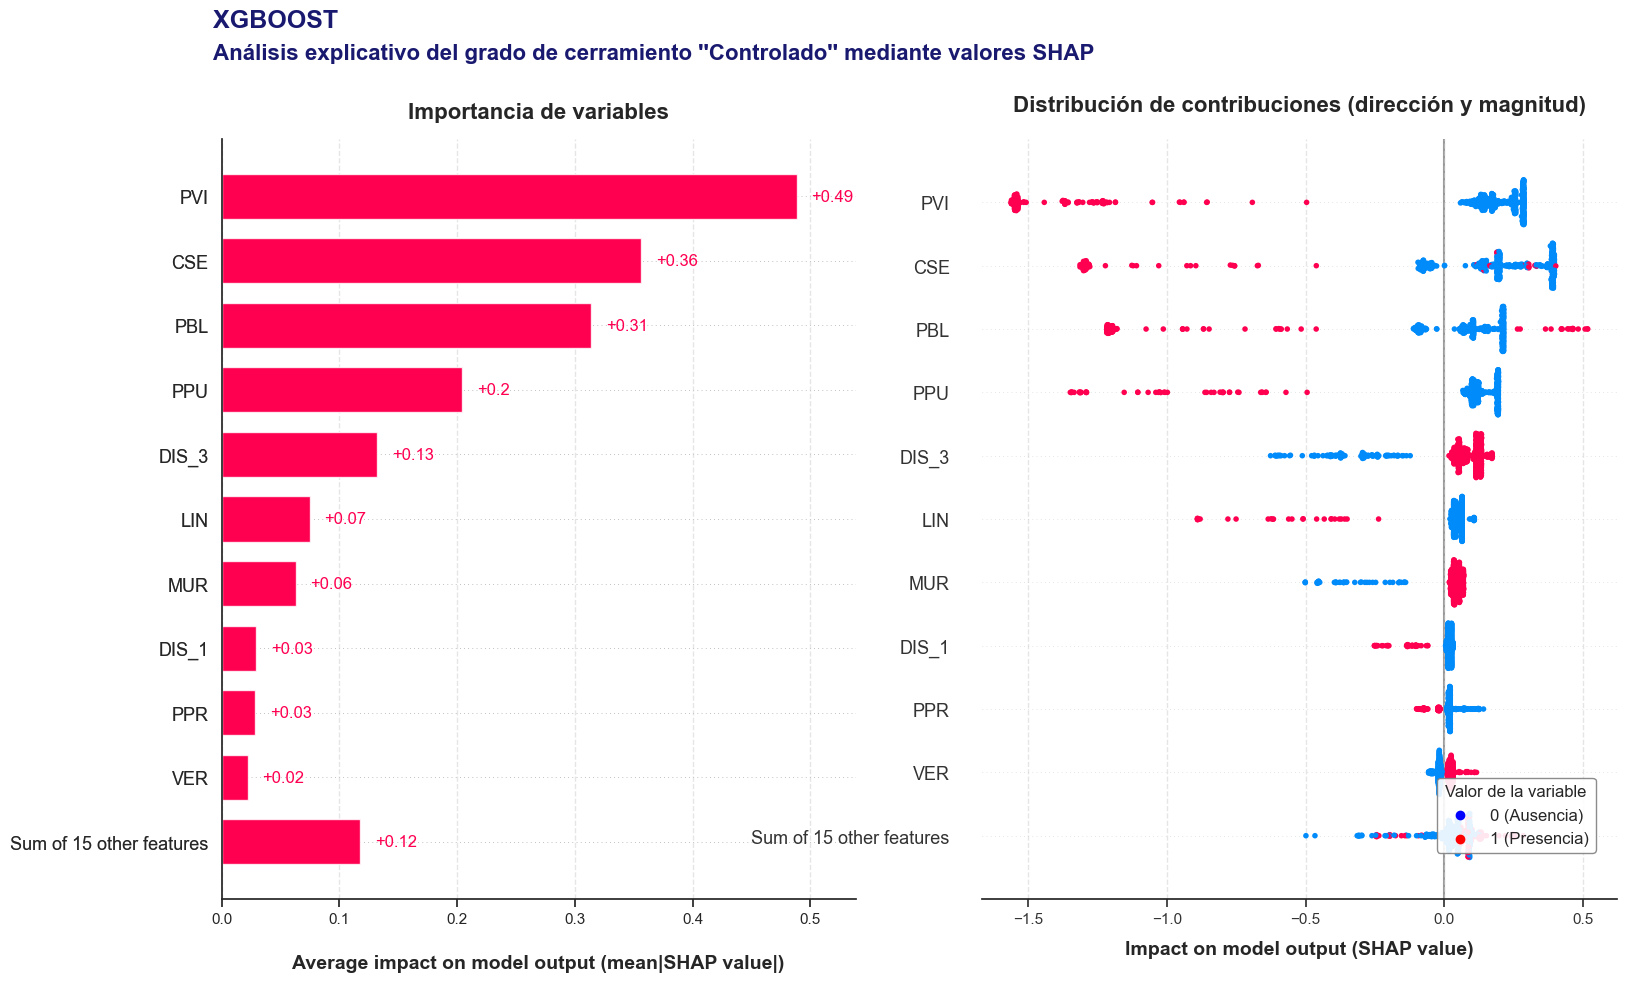

In [24]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Controlado", model_name="XGBoost", num_features_display=11)

En el grado de cerramiento "Controlado", las variables con mayor impacto en las predicciones del modelo son las cámaras de seguridad (**CSE**), el acceso por bloque (**PBL**) y por vivienda (**PVI**) y el uso público de la vía (**PPU**). Al analizar el gráfico *beeswarm*, se observa que la presencia de estas características genera valores SHAP notablemente negativos, actuando como factores inhibidores que alejan a la observación de esta categoría. 

De este modo, el análisis mediante SHAP permite obtener una interpretación conceptualmente similar a la derivada de los coeficientes del modelo de regresión logística. El grado de cerramiento “Controlado” comparte con “Protegido” la ausencia de espacios comunes, aunque se diferencia de este en la falta de servicios de seguridad como las cámaras (**CSE**), lo que reduce la intensidad de su cerramiento.

No obstante, se observa una ligera dispersión de valores SHAP positivos en las variables **CSE** y **PBL**, que contribuyen de forma moderada a la pertenencia a esta clase. Este comportamiento indica que, aunque estas variables actúan mayoritariamente como factores inhibidores a lo largo de la distribución, existen casos de mayor complejidad cuya interpretación puede diferir del patrón general para este grado de cerramiento.

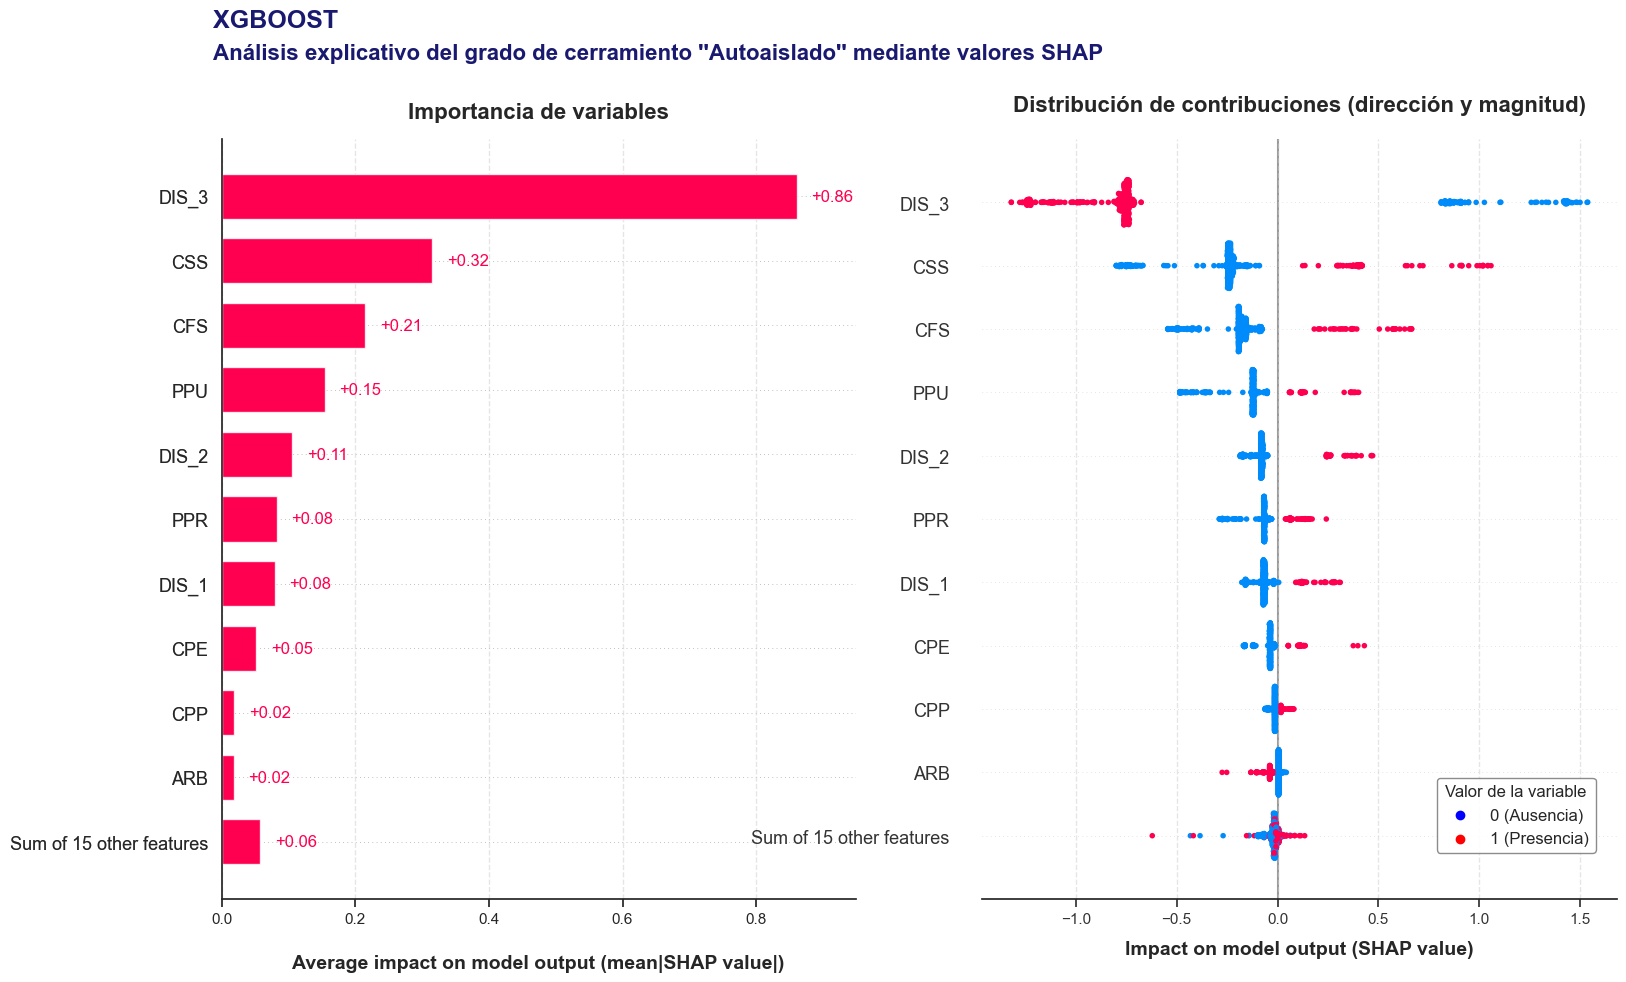

In [19]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Autoaislado", model_name="XGBoost", num_features_display=11)

El gráfico *beeswarm* de la clase “Autoaislado” muestra con claridad cómo determinadas variables actúan como catalizadores o inhibidores de este grado de cerramiento en función de su presencia o ausencia en el complejo residencial.

La variable **DIS_3** presenta el mayor impacto, de forma que su presencia actúa como un claro inhibidor, mientras que su ausencia contribuye a la predicción de esta clase. Tal y como se identificó en el análisis exploratorio, los complejos residenciales "Autoaislados" no se encuentran integrados en el núcleo úrbano.

En menor magnitud, la presencia de elementos estructurales disuasorios, como las calles sin salida (**CSS**) y las calles en fondo de saco (**CFS**), junto con el uso público (**PPU**) o privado (**PPR**) de la vía, contribuyen a la pertenencia a esta clase. Por el contrario, la ausencia de estas variables reduce la probabilidad de clasificación en este grado de cerramiento.

En conjunto, el grado de cerramiento “Autoaislado” queda definido por la falta de integración en el núcleo urbano y la presencia de elementos estructurales disuasorios, independientemente de su carácter público o privado.

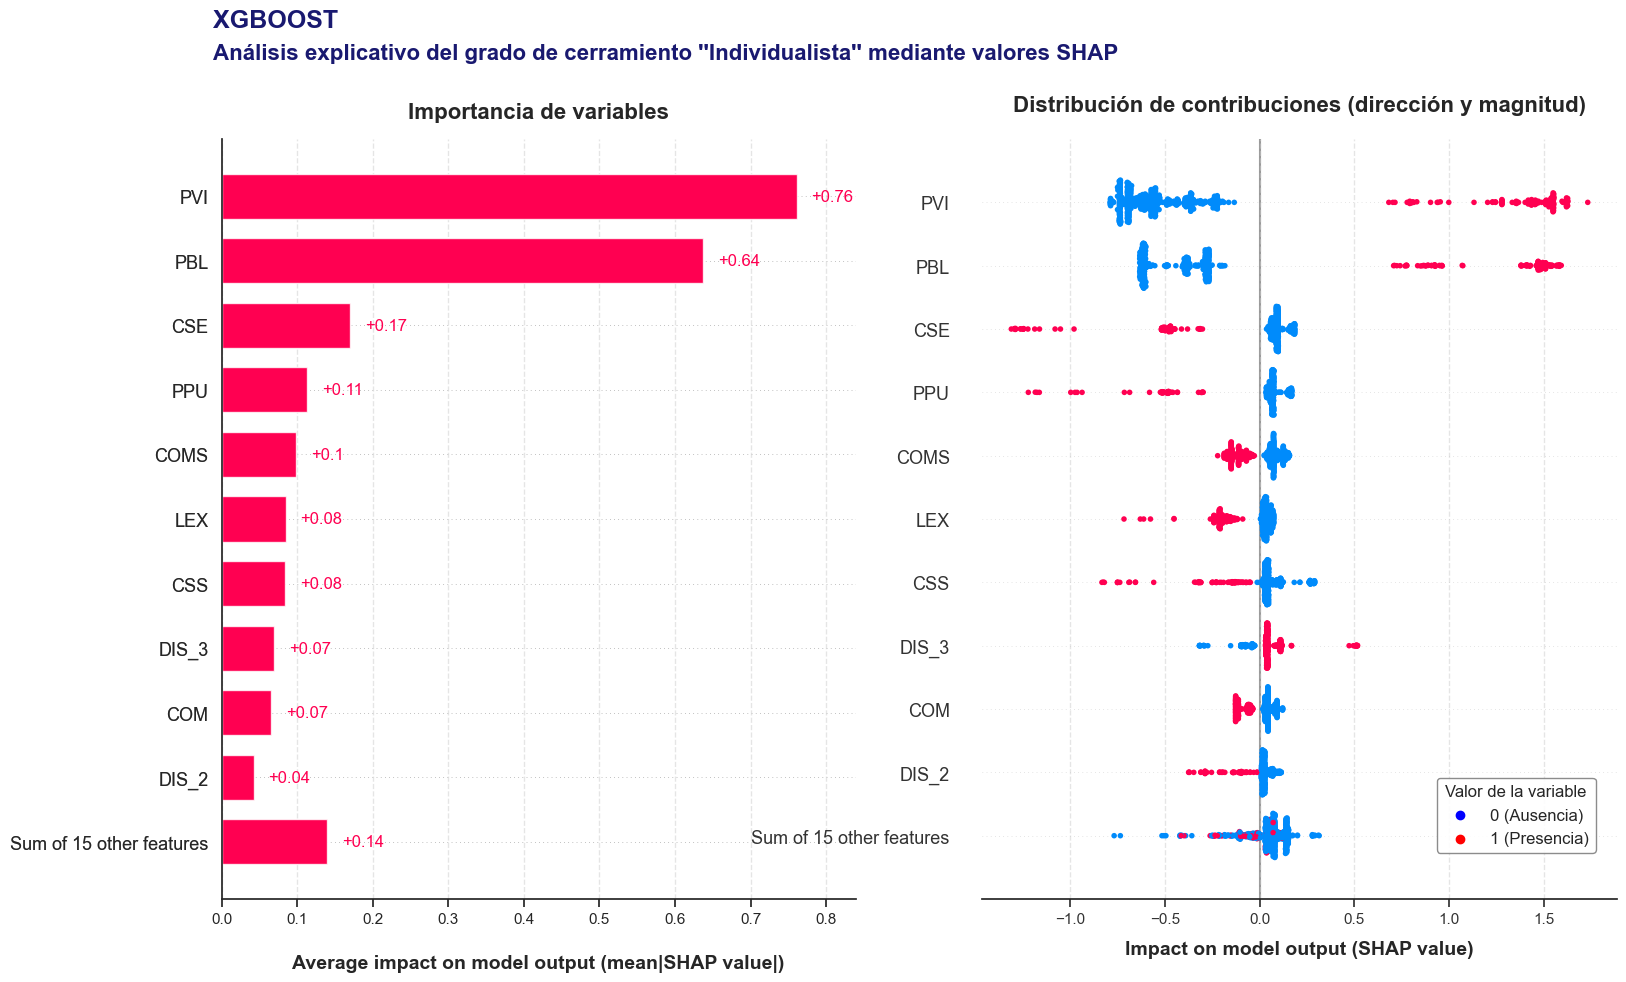

In [20]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Individualista", model_name="XGBoost", num_features_display=11)

En el grado de cerramiento "Individualista", las variables con mayor impacto en la salida del modelo son el acceso por vivienda (**PVI**) y el acceso por bloque (**PBL**). Al examinar el gráfico *beeswarm*, se observa que la presencia de estos tipos de acceso opera como un claro catalizador que incrementa la contribución hacia esta categoría, mientras que su ausencia actúa como un factor inhibidor.

Por otro lado, la presencia de cámaras de seguridad (**CSE**) y el uso público de la vía (**PPU**) alcanzan valores SHAP notablemente negativos por lo que reducen la contribución para que un complejo residencial sea clasificado como "Individualista".

El grado de cerramiento "Individualista" queda esencialmente definido por accesos individualizados (por vivienda o bloque). Este tipo de acceso puede propiciar que no haya espacios comunes para no residentes y que por tanto no sea necesario el uso de servicios de seguridad como las cámaras, lo cual es coherente con el impacto observado en las variables **CSE** y **PPU**.

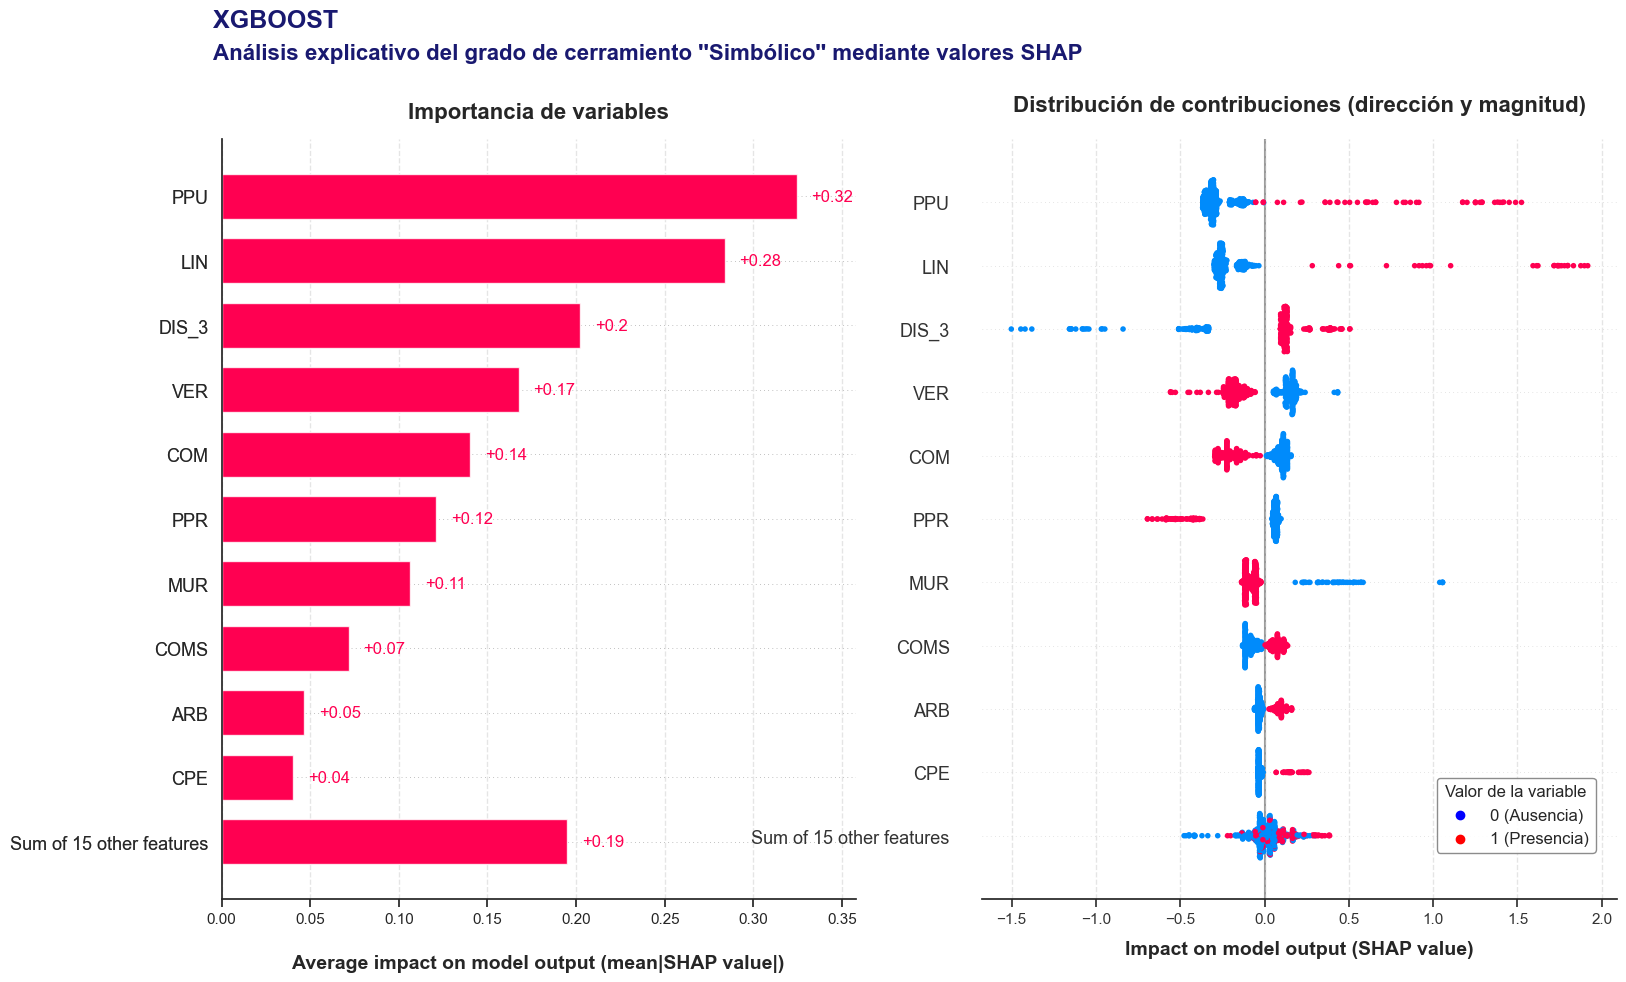

In [21]:
plot_shap_class_dashboard(cfg, shap_values_XG, class_label="Simbólico", model_name="XGBoost", num_features_display=11)

A diferencia de las categorías anteriores, en el grado de cerramiento "Simbólico" no se identifica una variable dominante cuyo impacto sea notablemente superior al resto. En este caso, un conjunto amplio de características presenta contribuciones moderadas y similares, lo que evidencia que se trata del grado de cerramiento más difuso de clasificar por el algoritmo y, por ende, el de interpretación más sutil.

De acuerdo con el gráfico *beeswarm*, los impactos positivos más relevantes se alcanzan con la presencia de comercios interiores (**LIN**) y el uso público de la vía (**PPU**). Ambas son características urbanas que favorecen de forma clara el tránsito de no residentes, lo que reduce la intensidad de cerramiento. En contraposición, se observa cómo la presencia de vías de uso privado (**PPR**) reduce la contribución a esta clase.

En sentido negativo, la ausencia de **DIS_3** es el factor que más penaliza la pertenencia a esta categoría. Esto indica que la ubicación de los complejos residenciales fuera del núcleo úrbano supone un nivel de cerramiento demasiado elevado para ser clasificado como "Simbólico".

En este grado de cerramiento, las variables del bloque "Tipos de cerramiento" como las verjas (**VER**) y los muros (**MUR**) están teniendo un impacto relevante en la salida del modelo. Se observa como la presencia de verjas reduce la contribución mientras que la ausencia de muros la aumenta. En ambos casos, se interpreta que la existencia de cerramientos de tipo "duro" no se alinea con este grado de cerramiento.

Puede concluirse que el grado de cerramiento "Simbólico" es el más sútil y que por tanto queda determinado por matices aportados por múltiples elementos urbanísticos que de forma conjunta consiguen que la intensidad de cerramiento percibida sea muy baja o inexistente. En este sentido las variables más importantes son el uso público de la vía, la presencia de comercios internos y la integración en el núcleo úrbano.

<a id="conclusiones"></a>
# 4. Discusión y conclusiones: balance entre interpretabilidad y rendimiento

El principal hallazgo del análisis de interpretabilidad global es la consistencia de las conclusiones urbanísticas obtenidas tanto en los modelos transparentes como en los modelos de tipo “caja negra”. Las variables identificadas como más relevantes mediante los distintos mecanismos de explicabilidad presentan un núcleo común compartido entre todos los modelos. Además, el análisis a nivel de clase muestra una caracterización muy homogénea de los distintos grados de cerramiento a partir de las variables que influyen en cada uno de ellos. En este sentido, las diferencias entre modelos son sutiles y aportan una visión complementaria del fenómeno, como ocurre en la categoría de cerramiento “Simbólico”, donde XGBoost incorpora variables que no resultan relevantes para otros modelos.

Estos resultados indican que el uso de SHAP como técnica de interpretabilidad post-hoc proporciona a los modelos de tipo “caja negra” un nivel de interpretabilidad conceptual comparable al que se consigue con los mecanismos intrínsecos de los modelos transparentes. Este hallazgo refuerza el uso de modelos caja negra puesto que la explicabilidad de los modelos es coherente con el conocimiento del dominio, lo que sugiere que el incremento de la capacidad predictiva no responde a correlaciones espurias ni a artefactos derivados de la complejidad del modelo, si no a una modelización más precisa de las mismas variables que utilizan los modelos más simples.

Una vez alcanzado un nivel de interpretabilidad comparable entre los modelos de tipo “caja negra” y los modelos transparentes, las principales diferencias residen en el rendimiento predictivo y en los propios mecanismos de interpretabilidad; es decir, en la forma en que el comportamiento interno del modelo se transforma en explicaciones comprensibles para expertos del dominio que no necesariamente conocen las particularidades algorítmicas del modelo ni de las técnicas de explicabilidad utilizadas.

Los mecanismos de interpretabilidad utilizados para interpretar la regresión logística y XGBoost proporcionan una interpretación aditiva mientras que las reglas de los árboles de decisión generan una interpretación condicional y fragmentada. En este sentido, las posibilidades de explicabilidad ofrecidas por los coeficientes de la regresión logística y los valores SHAP resultan conceptualmente similares, mientras que las reglas del árbol de decisión constituyen un enfoque interpretativo alternativo dentro del experimento realizado.

Se ha observado que las explicaciones obtenidas mediante mecanismos de interpretabilidad aditivos resultan más intuitivas para los expertos del dominio que las derivadas de reglas de decisión. Esto se debe a que las variables del conjunto de datos poseen un significado semántico individual y reconocible en el contexto urbanístico, que se puede relacionar directamente con la intensidad de cerramiento sin necesidad de variables adicionales.

En este sentido, tanto los coeficientes de la regresión logística como los valores SHAP generan interpretaciones cognitivamente naturales, basadas en contribuciones individuales de las variables sobre la predicción. Estas explicaciones pueden expresarse de forma directa mediante razonamientos del tipo: “la presencia de la característica $M$ incrementa o reduce la probabilidad de que el complejo residencial pertenezca al grado de cerramiento $K$”. De este modo, se establece una relación clara entre cada variable y los distintos grados de cerramiento a partir de la dirección e intensidad de su efecto.

Por el contrario, las reglas de los árboles de decisión requieren interpretar combinaciones secuenciales de variables sujetas a umbrales específicos, donde el significado de cada atributo depende del contexto definido por las decisiones previas. Esto implica analizar interacciones y jerarquías dentro de regiones concretas del espacio de decisión, dificultando la construcción de una interpretación global del fenómeno. Tal y como se ha mostrado en la sección [2.2 Caracterización de los grados de cerramiento mediante reglas de decisión](#22-caracterización-de-los-grados-de-cerramiento-mediante-reglas-de-decisión), cada grado de cerramiento queda descrito a través de múltiples reglas diferentes, por lo que no es sencillo extraer una narrativa única y compacta que describa patrones generales que caractericen cada grado de cerramiento.

Por ejemplo, el grado de cerramiento “Individualista” quedaba descrito mediante cinco reglas de decisión, en las que intervenía un número elevado de variables. En este caso, la variable **DIS_3** aparecía en el primer nivel del árbol debido a su capacidad para realizar una partición eficiente del espacio de decisión, aunque no constituía realmente un atributo discriminante específico para la categoría “Individualista”. Como consecuencia, la interpretación del grado de cerramiento quedaba distribuida entre múltiples reglas y condicionada por combinaciones sucesivas de variables que no reflejan de forma clara las variables realmente discriminantes en esta categoria.

Por el contrario, tanto la regresión logística como XGBoost mediante SHAP identifican de forma consistente los accesos por vivienda (**PVI**) y por bloque (**PBL**) como las principales variables catalizadoras de este grado de cerramiento, junto con otras variables que actuan como inhibidoras con menor intensidad. De este modo, los coeficientes y los valores SHAP permiten sintetizar el comportamiento del modelo mediante explicaciones más compactas y directas, facilitando la identificación de los factores catalizadores e inhbidores más representativos del grado de cerramiento.

Una de las posibles ventajas de los árboles de decisión es su capacidad para simplificar el problema mediante una selección implícita de variables, centrándose únicamente en aquellas que generan las particiones más eficientes del espacio de decisión. Sin embargo, en este problema concreto, dicha simplificación reduce tanto la capacidad predictiva como la capacidad explicativa del modelo

Esta situación puede observarse claramente en el bloque de variables relacionado con la “Seguridad y vigilancia”, cuya influencia resulta especialmente relevante en la clasificación del grado de cerramiento “Protegido”. En el caso del árbol de decisión, únicamente se utiliza la variable correspondiente a cámaras de seguridad (CSE), mientras que otras variables del mismo bloque, como guardia de seguridad (GSE), alarma de seguridad (ASE) y barrera de seguridad (BSE), no participan en las reglas generadas. Como consecuencia, el modelo reduce el concepto de seguridad a la presencia del elemento más frecuente. Esta simplificación implica que complejos residenciales que disponen de otros servicios de seguridad, pero carecen de cámaras, puedan ser clasificados incorrectamente por el árbol de decisión, afectando negativamente al rendimiento del modelo y limitando la representación conceptual del grado de cerramiento.

Por el contrario, tanto la regresión logística multinomial como XGBoost identifican una contribución conjunta del bloque “Seguridad y vigilancia” sobre la probabilidad de pertenencia a la clase “Protegido”. En concreto, el análisis mediante SHAP en XGBoost permite distinguir diferentes niveles de influencia dentro del propio bloque. Las cámaras de seguridad actúan como la variable más determinante, de modo que su presencia funciona como un factor claramente catalizador y su ausencia como un factor inhibidor. En cambio, el resto de servicios de seguridad desempeñan un papel complementario: su presencia contribuye positivamente a la pertenencia a esta categoría, aunque su ausencia no penaliza de forma significativa la predicción. Este comportamiento proporciona una explicación más realista y matizada de este grado de cerramiento.

Por estos motivos, el modelo transparente que se considera más adecuado para este problema es la regresión logística multinomial, ya que no solo supera al árbol de decisión en términos de capacidad predictiva, sino que además su mecanismo de interpretabilidad se ajusta mejor a la intuición explicativa del dominio.

Las diferencias en términos de interpretabilidad entre la regresión logística, a través de sus coeficientes, y XGBoost, mediante SHAP, son relativamente reducidas, ya que ambos enfoques se basan en una estructura aditiva. En el caso de la regresión logística, los coeficientes proporcionan una interpretación global directa del efecto de cada variable sobre la salida del modelo, al estar integrados explícitamente en su función de decisión. Por el contrario, SHAP aproxima el comportamiento de XGBoost mediante una descomposición aditiva de las predicciones en contribuciones individuales, calculadas a nivel local y posteriormente agregadas para obtener una visión global del modelo.

No obstante, la interpretación de la dirección y magnitud de la contribución de cada variable hacia un determinado grado de cerramiento es conceptualmente equivalente en ambos casos. En ambos mecanismos es posible identificar si una variable actúa como factor catalizador, incrementando la probabilidad de pertenencia a una clase, o como factor inhibidor, reduciéndola. Esto se ve refeljado en los gráficos de barras que se han utilizado para caracterizar los grados de cerramiento en la regresión logística que reflejan una lógica interpretativa muy similar a la de los gráficos beeswarm de SHAP, utilizados con el mismo propósito.

En términos de rendimiento, las diferencias globales entre los modelos no son especialmente acusadas. Sin embargo, a nivel desagregado por clase, XGBoost mejora de forma notable la precisión en el grado de cerramiento “Simbólico”. Este aspecto resulta especialmente relevante en un contexto donde la interpretabilidad del modelo es un objetivo de diseño. Alcanzar una precisión elevada en todas las clases es fundamental, ya que garantiza que las explicaciones derivadas sean representativas de patrones reales aprendidos a partir de muestras correctamente clasificadas. De lo contrario, las explicaciones pueden verse afectadas por observaciones pertenecientes a otras clases, introduciendo ruido en la interpretación del comportamiento del modelo.


Se concluye que el modelo más adecuado para su despliegue en producción es XGBoost, al presentar el mejor equilibrio entre capacidad predictiva e interpretabilidad. Desde el punto de vista del rendimiento, se posiciona como el modelo con mejores resultados tanto a nivel global como por clase. En términos de interpretabilidad, el uso de SHAP permite alcanzar un nivel comparable al de modelos transparentes como la regresión logística multinomial, proporcionando una forma de comunicación de las explicaciones alineada con la manera en que los expertos del dominio entienden el problema.